In [1]:
_MERKZETTEL = {}


def merke(schluessel, wert):
    """Haelt ein Ergebnis fuer den Fliesstext fest und gibt es zurueck."""
    _MERKZETTEL[schluessel] = wert
    return wert

# Anomalieerkennung: Was ist gestern schiefgelaufen?

**Verfahren:** Anomalieerkennung (unüberwacht — gesucht wird die Ausnahme, nicht die Regel)  |  **Geschäftsfrage:** Drei Fragen, drei Zeitpunkte: Welches Rad ist JETZT überfällig, welche abgeschlossenen Vorgänge verdienen heute früh einen Blick, und welche Station stand gestern still?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/06_Anomalieerkennung_Auffaellige_Vorgaenge.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Phase</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Leitfrage</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Business Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Was ist die Geschäftsfrage — und woran messen wir Erfolg?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Data Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche Daten haben wir, und taugen sie für diese Frage?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Data Preparation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Modeling</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welches Verfahren, welche Einstellungen, wie geprüft?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">5</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Evaluation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">6</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Deployment</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie kommt das Modell in den Betrieb — und was passiert danach?</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

> ### Kurzfassung
>
> **Fragestellung.** Drei Fragen mit drei unterschiedlichen Entscheidungszeitpunkten:
> Welches Rad ist gegenwärtig überfällig? Welche abgeschlossenen Vorgänge verdienen am
> Folgetag eine Prüfung? Welche Station war über längere Zeit ohne Bewegung?
>
> **Vorgehen.** Die erste Frage beantwortet eine Regel; ein Modell ist dafür nicht
> erforderlich. Für die zweite lernt ein Isolation Forest, welche Vorgänge als
> unauffällig gelten. Im ersten Anlauf trennte er die Preisklassen statt der Anomalien —
> bemerkt wurde das nicht anhand einer Kennzahl, sondern durch Sichtung der obersten
> Zeilen der Rangliste.
>
> **Ergebnis.** Produkt A1 ist spezifiziert: als Regel beschrieben und retrospektiv
> geprüft, doch Echtzeitquelle, Ausnahmeliste und Alarmkanal fehlen. Produkt A2 steht
> auf schatten, da für die Bewertung kein Label vorliegt. Bei Produkt B halten
> 2 von 3 bindenden Gates auf dem unangetasteten Testabschnitt; der Status lautet
> explorativ — explorativ entwickelte Regel; ein prospektiver Probebetrieb ist nötig — der Testabschnitt trägt die Freigabe nicht.
>
> **Was offen bleibt.** Die globale Rangliste erreicht 36,0 %, die im
> Betrieb tatsächlich erzeugbare Tagesliste dagegen 12,4 % — bei identischem
> Modell. Eine Kennzahl, die auf der Gesamtliste ermittelt wurde, beschreibt nicht die
> Liste, mit der später gearbeitet wird.

> **Lehrdatensatz.** Fahrten, Langzeitvorgänge und Stationsstörungen in dieser Fallstudie
> sind **synthetisch erzeugt** und didaktisch verstärkt: Die langen Fahrten und die
> Störungstage wurden absichtlich als Anker eingebaut, damit sich überhaupt etwas messen
> lässt. Alle Trefferquoten in diesem Notebook zeigen deshalb **das Verhalten der
> Verfahren**, nicht die Güte eines Betriebssystems. Für eine reale Freigabe zählt keine
> einzige Zahl von hier.

## Einordnung: Anomalieerkennung

Alle bisherigen Notebooks haben **Muster** gesucht. Dieses sucht die **Abweichung vom
Muster** — und dreht damit die übliche Frage um:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Frage</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Notebook 1–2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Was ist typisch für diesen Fall?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Notebook 3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche typischen Gruppen gibt es?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Notebook 5</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche typischen Zusammenhänge gibt es?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Notebook 6</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Was passt in keines dieser Muster?</strong></td></tr>
</tbody></table>
<div style="clear:both"></div>

Die Aufgabe ist schwieriger, als die Frage vermuten lässt. Die eigentliche
Schwierigkeit liegt nicht darin, Ausreißer zu finden — das leistet jedes Verfahren mit
wenigen Zeilen Code. Sie liegt in der Frage danach:

> **Auffällig ist nicht dasselbe wie problematisch.**

Ein Notebook, das tausend Auffälligkeiten ausspuckt, hat den Betrieb nicht entlastet,
sondern beschäftigt. Deshalb steht hier — mehr noch als in den anderen — die
Priorisierung im Mittelpunkt.

**Und dieses Notebook enthält ein negatives Ergebnis.** Eine der beiden Aufgaben, die wir
uns in Phase 1 stellen, lässt sich mit diesen Daten **nicht** lösen. Warum das so ist und
was daraus folgt, ist der lehrreichste Teil — im Berufsleben ist ein sauber begründetes
„geht nicht“ mehr wert als ein geschöntes „geht doch“.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Der Betrieb hat morgens eine halbe Stunde. Was soll er sich ansehen?

### Die Ausgangslage

Im Betriebsbüro sitzt morgens jemand, der den Vortag durchsieht — heute stichprobenhaft,
bei wachsendem Netz nicht mehr machbar. Gesucht ist eine **kurze Tagesliste**, die einen
menschlichen Blick verdient. Wie kurz, wird ausgerechnet, nicht gesetzt.

### Drei Produkte mit drei Zeitpunkten

Die naheliegende Fassung der Aufgabe lautet „eine Liste mit den auffälligsten Vorgängen
von gestern". Sie ist falsch, und der Fehler liegt im **Zeitpunkt**: Ein Rad, das seit
vierzehn Stunden unterwegs ist, muss **jetzt** gesucht werden. Eine teure Fahrt von
gestern kann warten. Und eine stillstehende Station betrifft eine andere
Beobachtungseinheit — dort ist ein *Stationstag* der Fall, keine Fahrt.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Produkt</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Wann entschieden wird</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Datengrundlage</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Wer handelt</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A1</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>offene Rückgaben</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">laufend, in Echtzeit</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Vorgänge, die <strong>noch offen</strong> sind</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Betrieb kontaktiert und sucht</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A2</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>auffällige abgeschlossene Fahrten</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">morgens, über den Vortag</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Fahrten, die <strong>bereits beendet</strong> sind</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Betriebsbüro prüft am Schreibtisch</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>auffällige Stationstage</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">morgens, über den Vortag</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Stationstage</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Technik prüft das Terminal</td></tr>
</tbody></table>
<div style="clear:both"></div>

Diese Trennung steht **vor** der Verfahrenswahl. Werden A1 und A2 in einer Liste
zusammengefasst, wird die Maßnahme „Rad bergen, bevor es verschwindet" mit
**abgeschlossenen** Fahrten begründet — bei denen das Rad längst zurück ist. Die Liste
wäre korrekt gerechnet und für ihren Zweck unbrauchbar. Der Entscheidungszeitpunkt
bestimmt, welche Daten vorliegen und welche Maßnahme überhaupt möglich ist.

### Nutzen eines Funds, Kosten eines Fehlalarms

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Kosten</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>gefundene echte Auffälligkeit</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Rad wird geborgen, bevor es verschwindet</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Nutzen 120 €</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Fehlalarm</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">jemand sieht sich einen Vorgang an, der in Ordnung war</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>6 €</strong> (fünf Minuten)</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>übersehene Auffälligkeit</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Rad bleibt liegen, wird gestohlen oder beschädigt</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Verlust 120 €</strong></td></tr>
</tbody></table>
<div style="clear:both"></div>

**Ab rund 5 % Trefferquote rechnet sich die Liste** — ein Fund trägt neunzehn
Fehlalarme. Das ist typisch für Anomalieerkennung: Man darf sich viel Ungenauigkeit
leisten, solange die Fälle selten und die Funde wertvoll sind.

**Diese 5 % sind aber nicht das Erfolgskriterium.** Eine Liste, bei der neunzehn von
zwanzig Einträgen unnötig sind, öffnet nach zwei Wochen niemand mehr — dann ist der
rechnerische Nutzen null. Angesetzt werden deshalb **20 %**: jeder fünfte Eintrag muss
tragen. Der Unterschied zwischen „rechnet sich" und „wird benutzt" ist der Grund, warum
Erfolgskriterien nicht aus einer Kostenrechnung allein folgen.

**Die Listenlänge wird ebenfalls gerechnet.** Das Betriebsbüro hat morgens eine halbe
Stunde, eine Prüfung dauert fünf Minuten — das sind sechs Fälle, nicht zehn. Zehn
Prüfungen bräuchten 50 Minuten.

### Erfolgskriterien je Produkt

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Produkt</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Kriterium</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Schwelle</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Prüfbar?</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A1</strong> offene Rückgaben</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">jeder offene Vorgang über der Schwelle wird gemeldet, <strong>bevor</strong> er endet</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Vollständigkeit</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nur logisch</strong> — Label und Regel benutzen dieselbe 8-Stunden-Grenze</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A2</strong> auffällige Fahrten</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Liste ≤ Kapazität, jede Zeile mit Begründung</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Kapazität und Nachvollziehbarkeit</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A2</strong> auffällige Fahrten</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Trefferquote</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nicht festlegbar</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nein</strong> — siehe unten</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B1</strong> Stationsstörungen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Präzision je <strong>neuem Alarm</strong> (dedupliziert)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">≥ 20 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja, gegen <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">stationsstoerung.csv</code></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B2</strong> Stationsstörungen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Recall je <strong>Störungsepisode</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">≥ 60 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B3</strong> Stationsstörungen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Verzug bis zum ersten Alarm</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">≤ 1 Tag</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B4</strong> Stationsstörungen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Alarme je Tag im Mittel, <strong>Technikkapazität</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">≤ 6</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ja</td></tr>
</tbody></table>
<div style="clear:both"></div>

<details style="margin:12px 0 18px 0;border-left:3px solid #D8D8D8;padding-left:14px"><summary style="cursor:pointer;color:#2F2F2F;font-weight:600;padding:2px 0">Warum Produkt B vier Kriterien braucht</summary><div style="color:#333333;line-height:1.55;padding-top:8px"><p>Eine Regel, die fast nie meldet, erfüllt eine Präzisionshürde mühelos und übersieht dabei fast jede Störung. Präzision ohne Recall ist deshalb kein Gütemaß. Umgekehrt ist ein hoher Recall wertlos, wenn die Liste im Betrieb nicht abgearbeitet werden kann — daher B4.</p><p><strong>Jede Zahl nennt ihren Nenner.</strong> „Je gemeldetem Stationstag“, „je neuem Alarm“ und „je Störungsepisode“ sind drei verschiedene Einheiten, in denen dieselbe Regel sehr verschieden aussieht. Bindend ist der <strong>neue Alarm</strong> — die Einheit, die einen Technikereinsatz auslöst.</p><p><strong>Zu B4 gehört eine offene Annahme.</strong> Die Kapazität von 6 Alarmen je Tag stammt aus dem Zeitbudget des Betriebsbüros, also aus Produkt A. Bei B fährt die Technik hin; deren Zeitbudget liegt nicht vor. B4 ist deshalb eine Platzhalterschwelle und wird ausgewiesen, aber <strong>nicht freigabebindend</strong> ausgewertet.</p><p>B2 bis B4 wurden gegenüber der ersten Fassung ergänzt — <strong>bevor</strong> der Testabschnitt geöffnet wurde. Das ist der einzige Zeitpunkt, zu dem eine solche Ergänzung zulässig ist.</p></div></details>

**Für A2 gibt es bewusst kein Trefferkriterium.** Eine Trefferquote braucht ein Label;
für „unbekannte Auffälligkeiten" gibt es per Definition keines. Was vorliegt, ist eine
**Teilwahrheit** — Fahrten über acht Stunden —, und die misst nur, wie gut das Modell
eine Regel nachbaut, die ohnehin vorhanden ist. Der einzige belastbare Weg für A2 ist
der **Schattenbetrieb**: Die Liste läuft mit, jemand beurteilt jede Zeile, und
**danach** lässt sich eine Trefferquote nennen. Bis dahin ist A2 eine Hypothesenliste,
kein Erkennungssystem.

**Ein Kriterium fehlt und gehört in eine zweite Runde:** eine Zufallsstichprobe aus den
**nicht** gemeldeten Vorgängen. Ohne sie bleibt unbekannt, wie viele Probleme die Liste
übersieht — sichtbar sind nur die, die sie zeigt.

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Bevor irgendein Verfahren läuft: Wie sieht normal überhaupt aus?

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ─── DARSTELLUNG ────────────────────────────────────────────────────
# Farben und Helfer fuer Tabellen und interaktive Diagramme. Rein
# kosmetisch: Keine Zahl und kein Urteil dieses Notebooks haengt daran.
FARBE = {
    "akzent": "#2F2F2F", "akzent_hell": "#767676",
    "flaeche": "#FAFAFA", "flaeche_dunkel": "#EFEFEF",
    "linie": "#D8D8D8", "text": "#333333",
    "gut": "#4A4A4A", "warnung": "#8C2F39",
    "reihe": ['#2F2F2F', '#767676', '#8C2F39', '#A8A8A8', '#5A5A5A', '#C4C4C4'],
}


def stil(rahmen, balken=None, prozent=None):
    """Ergebnistabelle mit Balken in einer Spalte und linksbuendigem Kopf."""
    s = (rahmen.style
         .set_table_styles([
             {"selector": "th", "props": [("text-align", "left"),
              ("border-bottom", "2px solid " + FARBE["akzent"]),
              ("color", FARBE["akzent"]), ("padding", "6px 14px 6px 0")]},
             {"selector": "td", "props": [("text-align", "left"),
              ("border-bottom", "1px solid " + FARBE["linie"]),
              ("padding", "5px 14px 5px 0")]}])
         .hide(axis="index"))
    if balken:
        s = s.bar(subset=[balken], color=FARBE["akzent_hell"], vmin=0)
    if prozent:
        s = s.format({spalte: "{:.1%}" for spalte in prozent})
    return s


def interaktiv(fig, titel="", hoehe=420):
    """Zeigt ein Plotly-Diagramm — in Colab bedienbar, auf GitHub nicht.

    Plotly wird ueber das CDN geladen; die Zelle bleibt dadurch bei rund
    acht Kilobyte. GitHub entfernt solche Skripte beim Rendern, deshalb
    steht jede freigaberelevante Aussage zusaetzlich in einer statischen
    Grafik oder in einer Textausgabe.
    """
    from IPython.display import HTML, display
    fig.update_layout(
        title=dict(text=titel, font=dict(size=15, color=FARBE["akzent"])),
        height=hoehe, margin=dict(l=60, r=20, t=50 if titel else 20, b=50),
        plot_bgcolor="white", paper_bgcolor="white",
        font=dict(family="system-ui, -apple-system, sans-serif", size=12,
                  color=FARBE["text"]),
        colorway=FARBE["reihe"],
        hoverlabel=dict(bgcolor="white", bordercolor=FARBE["linie"]),
        legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0))
    fig.update_xaxes(showgrid=True, gridcolor=FARBE["flaeche_dunkel"],
                     zeroline=False, linecolor=FARBE["linie"])
    fig.update_yaxes(showgrid=True, gridcolor=FARBE["flaeche_dunkel"],
                     zeroline=False, linecolor=FARBE["linie"])
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False,
                             config={"displaylogo": False})))


# Die Adresse zeigt auf den Zweig 'main' - der sich aendern kann. Fuer eine
# Auswertung, die spaeter exakt reproduzierbar sein muss, gehoert hier ein
# fester Commit-Hash statt 'main' hinein.
BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/91119429f347b80f754315d8ce054d2bea3b8310/analytics/")
pd.set_option("display.width", 160)

# Die Zahlen aus Phase 1 - hier ausgedruckt, damit Text und Rechnung nicht
# auseinanderlaufen koennen. Beide Schwellen werden ABGELEITET, nicht gesetzt.
NUTZEN_FUND = 120.0        # geborgenes Rad statt Verlust
# Acht Stunden. Die Zahl steht EINMAL - sie definiert die Teilwahrheit,
# und der Fliesstext beruft sich darauf.
LANGFAHRT_MIN = merke("langfahrt_min", 8 * 60)
KOSTEN_FEHLALARM = 6.0     # fuenf Minuten Ansehen ohne Befund
KRITERIUM_TREFFER = merke("kriterium_treffer", 0.20)  # Erfolgskriterium fuer B

ZEITBUDGET_MIN = 30.0      # was das Betriebsbuero morgens hat
PRUEFDAUER_MIN = 5.0       # was eine Pruefung kostet
MORGENSTUNDE = 8           # wann die Liste auf dem Schreibtisch liegt

schwelle = KOSTEN_FEHLALARM / (NUTZEN_FUND + KOSTEN_FEHLALARM)
LISTENLAENGE = int(ZEITBUDGET_MIN // PRUEFDAUER_MIN)
print(f"Ein Fund ist {NUTZEN_FUND:.0f} EUR wert, ein Fehlalarm kostet "
      f"{KOSTEN_FEHLALARM:.0f} EUR.")
print(f"Rentabel ist die Liste ab {schwelle:.1%} Trefferquote - "
      f"ein Fund traegt {NUTZEN_FUND/KOSTEN_FEHLALARM:.0f} Fehlalarme.")
print(f"Gefordert werden fuer Aufgabe B trotzdem {KRITERIUM_TREFFER:.0%}: Eine Liste "
      f"voller Fehlalarme wird nicht benutzt.")
print(f"\nListenlaenge = {ZEITBUDGET_MIN:.0f} min Zeitbudget / {PRUEFDAUER_MIN:.0f} min "
      f"je Pruefung = {LISTENLAENGE} Plaetze.")
# Diese Zahl wird nirgends von Hand ueberschrieben - sonst behauptet der
# Text eine Kapazitaet, die der Code nicht einhaelt.

# ─── DER GATE-KATALOG FUER AUFGABE B - VOLLSTAENDIG UND VORAB ───────
#
# Ein einzelnes Praezisionskriterium ist manipulierbar: Eine Regel, die
# fast nie meldet, erfuellt es leicht und uebersieht fast jede Stoerung.
# Deshalb stehen hier VIER Huerden, und jede nennt ihren NENNER - ohne
# Nenner ist eine Quote keine Aussage.
#
# Diese Fassung des Katalogs ist eine dokumentierte Ueberarbeitung von
# Phase 1: Die vorige kannte nur B1. Sie wurde festgelegt, BEVOR der
# Testabschnitt geoeffnet wurde (siehe Phase 2) - das ist der einzige
# Zeitpunkt, zu dem so eine Ergaenzung noch zulaessig ist.
B_GATE = {
    "B1 Praezision je NEUEM ALARM":      KRITERIUM_TREFFER,
    "B2 Recall je STOERUNGSEPISODE":     0.60,
    "B3 Verzug bis zum ersten Alarm":    1,      # Tage, Maximum
    "B4 Alarme je Tag im Mittel":        float(ZEITBUDGET_MIN // PRUEFDAUER_MIN),
}
# Begruendungen, damit die Zahlen nicht als gesetzt dastehen:
#   B1  Eine Liste, die zu vier Fuenfteln aus Fehlalarmen besteht, wird
#       nach zwei Wochen nicht mehr geoeffnet. Betriebliche Erfahrung,
#       keine Rechnung - und deshalb strenger als die Rentabilitaets-
#       schwelle weiter unten.
#   B2  Unter der Haelfte traegt weiter die Kundenmeldung den Prozess;
#       dann ist die Regel ein Beiwerk und kein Produkt. 60 Prozent ist
#       die naechste runde Marke darueber.
#   B3  Zwei Tage Ausfall bemerkt die Kundschaft vor uns. Ein Tag ist
#       die Grenze, ab der die Meldung dem Betrieb noch etwas nuetzt.
#   B4  Die Kapazitaet des Betriebsbueros - dieselbe Rechnung wie fuer
#       Produkt A, weil dieselben Leute die Liste abarbeiten.
#
# EIGENE KOSTEN FUER B, nicht die von A2. Die 120/6 EUR beschreiben die
# Suche nach einem FAHRRAD durch das Betriebsbuero. Bei einer Station
# faehrt die Technik hin und prueft ein Terminal. Diese Zahlen liegen
# NICHT vor; sie sind ausdrueckliche ANNAHMEN und muessen vom Betrieb
# bestaetigt werden, bevor B in den Wirkbetrieb geht.
B_KOSTEN_PRUEFUNG = 25.0    # ANNAHME: Anfahrt und Terminalpruefung
B_NUTZEN_FUND = 300.0       # ANNAHME: frueh erkannt statt tagelang aus
B_SCHWELLE_RENTABEL = B_KOSTEN_PRUEFUNG / (B_NUTZEN_FUND + B_KOSTEN_PRUEFUNG)
for _n, _w in (("b_gate_praezision", B_GATE["B1 Praezision je NEUEM ALARM"]),
               ("b_gate_recall", B_GATE["B2 Recall je STOERUNGSEPISODE"]),
               ("b_gate_verzug", B_GATE["B3 Verzug bis zum ersten Alarm"]),
               ("b_gate_kapazitaet", B_GATE["B4 Alarme je Tag im Mittel"]),
               ("b_kosten_pruefung", B_KOSTEN_PRUEFUNG),
               ("b_nutzen_fund", B_NUTZEN_FUND),
               ("b_schwelle_rentabel", B_SCHWELLE_RENTABEL)):
    merke(_n, _w)
print("GATE-KATALOG FUER AUFGABE B - vorab, vollstaendig, mit Nenner:")
for _bez, _w in B_GATE.items():
    _e = "Tage" if "Verzug" in _bez else ("Alarme" if "je Tag" in _bez else "")
    print(f"   {_bez:<34s} {_w if _e else format(_w, '.0%'):>6} {_e}")
print(f"   Rentabel waere B schon ab {B_SCHWELLE_RENTABEL:.1%} je Alarm "
      f"({B_KOSTEN_PRUEFUNG:.0f} / {B_NUTZEN_FUND:.0f} EUR, ANNAHMEN).")
print("   B1 ist strenger als die Rentabilitaet - eine Liste muss benutzt")
print("   werden, nicht nur rechnerisch aufgehen.")

fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])
raeder = pd.read_csv(BASIS + "fahrrad.csv")
stationen = pd.read_csv(BASIS + "station.csv")
stoerungen = pd.read_csv(BASIS + "stationsstoerung.csv", parse_dates=["von", "bis"])

fahrten = fahrten.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
fahrten["dauer_min"] = (fahrten.endzeit - fahrten.startzeit).dt.total_seconds() / 60

print("Status aller Vorgänge:")
print(fahrten.status.value_counts().to_string())
_status = fahrten.status.value_counts()
merke("n_abgebrochen", int(_status.get("abgebrochen", 0)))
merke("n_storniert", int(_status.get("storniert", 0)))
print(f"\n{_status.get('abgebrochen', 0)} Abbrueche, {_status.get('storniert', 0)} "
      f"Stornierungen - beide bleiben in diesem Notebook aussen vor.")

echte = fahrten[fahrten.status == "abgeschlossen"].copy()
print(f"\nFahrtdauer in Minuten — die Quantile sagen mehr als der Mittelwert:")
print(echte.dauer_min.quantile([.5, .9, .99, .999, 1.0]).round(1).to_string())

# ZEITLICHE TRENNUNG - AUCH BEI EINEM UNUEBERWACHTEN VERFAHREN.
#
# Der Isolation Forest lernt keinen Zielwert, aber er lernt einen
# REFERENZZUSTAND: was normal ist. Fittet man ihn auf allen drei Jahren und
# bewertet dann eine Tagesliste vom Maerz 2024, kennt dieser Referenzzustand
# die Zukunft dieses Tages. Dasselbe gilt fuer die typspezifischen Mittel-
# werte und den Skalierer.
#
# Deshalb: die ersten zwei Drittel sind Referenz, das letzte Drittel wird
# nur bewertet - nie gelernt.
# DER SCHNITT IST EIN ZEITSTEMPEL, KEIN DATUM - UND ER LIEGT AUF EINEM
# LAUFZEITPUNKT.
#
# Eine fruehere Fassung rechnete den Schnitt aus normalisierten Startagen
# und bekam dabei 2025-08-26 08:00 heraus - gedruckt wurde aber nur das
# Datum. Zwei Folgen:
#   1. 74 Fahrten galten als Referenz, endeten aber nach dem Schnitt. Das
#      Modell sah sie beim Anpassen UND spaeter in der Auswertung.
#   2. Ein Vorgang fiel zwischen die Stuehle: gestartet im Pruefzeitraum,
#      beendet vor dem ersten Lauf - er wurde nie verarbeitet.
#
# Beides verschwindet, wenn man nach dem ABSCHLUSS trennt und den Schnitt
# auf einen Laufzeitpunkt legt. Das ist auch fachlich richtig: Ein
# periodischer Lauf sieht Vorgaenge, wenn sie ABGESCHLOSSEN sind.
MORGENSTUNDE_TD = pd.Timedelta(hours=MORGENSTUNDE)
tage_alle = echte.startzeit.dt.normalize()
A2_SCHNITT = ((tage_alle.min() + (tage_alle.max() - tage_alle.min()) * 2 // 3)
              .normalize() + pd.Timedelta(days=1) + MORGENSTUNDE_TD)
REFERENZ_BIS = A2_SCHNITT      # ein Name, ein Wert, ein Zeitstempel

# ─── DER DRITTE ABSCHNITT - UND WARUM ES IHN BRAUCHT ────────────────
#
# Fuer Produkt A reichen zwei Abschnitte: Der Isolation Forest lernt auf
# der Referenz, bewertet wird danach. Fuer Produkt B reicht das NICHT.
# Die Stationsregel wurde nachgebessert, NACHDEM ihr erstes Ergebnis
# vorlag - zwei Nulltage in Folge, Mindestbetrieb. Beides ist fachlich
# begruendet, aber es ist Entwicklung, und Entwicklung verbraucht den
# Zeitraum, auf dem sie stattfindet.
#
# Wer danach auf demselben Zeitraum freigibt, legitimiert genau die
# Testsatz-Nachnutzung, vor der diese Reihe an vier Stellen warnt.
#
# Deshalb wird der Pruefzeitraum halbiert:
#   ENTWICKLUNG  - hier wurde die Regel gebaut und darf gebaut werden
#   TEST         - unangetastet; hier faellt das Urteil ueber B
#
# Die Parameter der Regel stehen VOR dieser Zeile fest (Phase 1 und der
# Block "DIE REGEL, EINGEFROREN"). Danach wird nichts mehr gedreht.
_pz_tage = tage_alle[tage_alle >= A2_SCHNITT.normalize()]
B_ENTWICKLUNG_BIS = (_pz_tage.min()
                     + (_pz_tage.max() - _pz_tage.min()) / 2).normalize()
merke("b_entwicklung_bis", B_ENTWICKLUNG_BIS.strftime("%d.%m.%Y"))
merke("b_test_ab", (B_ENTWICKLUNG_BIS + pd.Timedelta(days=1)).strftime("%d.%m.%Y"))
print(f"\nFuer Produkt B ein DRITTER Abschnitt:")
print(f"   Entwicklung  bis {B_ENTWICKLUNG_BIS:%d.%m.%Y}   (hier wurde die Regel gebaut)")
print(f"   Test         ab  {B_ENTWICKLUNG_BIS + pd.Timedelta(days=1):%d.%m.%Y}   "
      f"(unangetastet - hier faellt das Urteil)")

referenz = echte[echte.endzeit < A2_SCHNITT].copy()
pruefzeit = echte[echte.endzeit >= A2_SCHNITT].copy()
print(f"\nSchnitt am Laufzeitpunkt {A2_SCHNITT:%d.%m.%Y %H:%M} Uhr - getrennt wird")
print("nach dem ABSCHLUSS eines Vorgangs, nicht nach seinem Start.")
print(f"   Referenz (vorher abgeschlossen):  {len(referenz):,d} Fahrten"
      .replace(",", "."))
print(f"   Pruefung (danach abgeschlossen):  {len(pruefzeit):,d} Fahrten"
      .replace(",", "."))
assert len(referenz) + len(pruefzeit) == len(echte), "Fahrten gehen verloren"

Ein Fund ist 120 EUR wert, ein Fehlalarm kostet 6 EUR.
Rentabel ist die Liste ab 4.8% Trefferquote - ein Fund traegt 20 Fehlalarme.
Gefordert werden fuer Aufgabe B trotzdem 20%: Eine Liste voller Fehlalarme wird nicht benutzt.

Listenlaenge = 30 min Zeitbudget / 5 min je Pruefung = 6 Plaetze.
GATE-KATALOG FUER AUFGABE B - vorab, vollstaendig, mit Nenner:
   B1 Praezision je NEUEM ALARM          20% 
   B2 Recall je STOERUNGSEPISODE         60% 
   B3 Verzug bis zum ersten Alarm          1 Tage
   B4 Alarme je Tag im Mittel            6.0 Alarme
   Rentabel waere B schon ab 7.7% je Alarm (25 / 300 EUR, ANNAHMEN).
   B1 ist strenger als die Rentabilitaet - eine Liste muss benutzt
   werden, nicht nur rechnerisch aufgehen.
Status aller Vorgänge:
status
abgeschlossen    104401
abgebrochen        2326
storniert           570

2326 Abbrueche, 570 Stornierungen - beide bleiben in diesem Notebook aussen vor.

Fahrtdauer in Minuten — die Quantile sagen mehr als der Mittelwert:
0.500      15.0
0

### 2.1 Die Verteilung und ihr Ausläufer

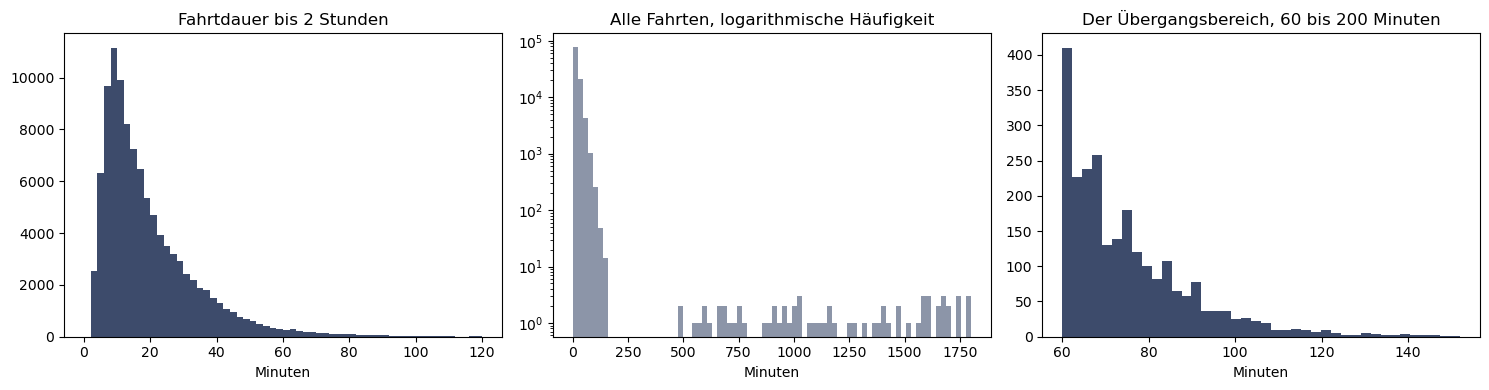

Fahrten über  2 Stunden:   109
Fahrten über  3 Stunden:    67
Fahrten über  8 Stunden:    67
längste Fahrt:            30.0 Stunden


In [3]:
fig, achsen = plt.subplots(1, 3, figsize=(15, 4))
achsen[0].hist(echte.dauer_min, bins=60, range=(0, 120), color="#3d4b6b")
achsen[0].set_title("Fahrtdauer bis 2 Stunden"); achsen[0].set_xlabel("Minuten")

achsen[1].hist(echte.dauer_min, bins=80, color="#8c95a8"); achsen[1].set_yscale("log")
achsen[1].set_title("Alle Fahrten, logarithmische Häufigkeit"); achsen[1].set_xlabel("Minuten")

lang = echte[echte.dauer_min > 180]
achsen[2].hist(echte.loc[echte.dauer_min.between(60, 200), "dauer_min"], bins=40, color="#3d4b6b")
achsen[2].set_title("Der Übergangsbereich, 60 bis 200 Minuten"); achsen[2].set_xlabel("Minuten")
plt.tight_layout(); plt.show()

# DIE LUECKE ZUM NACHMESSEN. Wo genau die Verteilung abreisst, entscheidet
# spaeter die Schwelle fuer Produkt A1; im festen Bild laesst sich das nur
# ungefaehr ablesen. Die statischen Bilder oben bleiben stehen.
# VORHER BINNEN, DANN SENDEN. go.Histogram schickt jeden einzelnen Wert
# an den Browser; bei ueber hunderttausend Fahrten blaeht das die Datei um
# ein Vielfaches. Die Klassen stehen hier ohnehin fest.
_h = echte.dauer_min[echte.dauer_min.between(30, 300)]
_anzahl, _kanten = np.histogram(_h, bins=90, range=(30, 300))
_mitte = (_kanten[:-1] + _kanten[1:]) / 2
_fig = go.Figure(go.Bar(x=_mitte, y=_anzahl, width=(_kanten[1] - _kanten[0]),
                        hovertemplate=("%{x:.0f} Minuten<br>%{y} Fahrten"
                                       "<extra></extra>")))
_fig.update_xaxes(title="Minuten", dtick=30)
_fig.update_yaxes(title="Fahrten")
interaktiv(_fig, "Fahrtdauer zwischen 30 und 300 Minuten - wo reißt die Verteilung ab?")

print(f"Fahrten über  2 Stunden: {int((echte.dauer_min > 120).sum()):>5d}")
print(f"Fahrten über  3 Stunden: {int((echte.dauer_min > 180).sum()):>5d}")
print(f"Fahrten über  8 Stunden: {int((echte.dauer_min > LANGFAHRT_MIN).sum()):>5d}")
print(f"längste Fahrt:           {echte.dauer_min.max()/60:>5.1f} Stunden")

**Das mittlere Bild zeigt eine Lücke**, und die ist der eigentliche Fund dieser Phase:
Zwischen etwa zwei und acht Stunden liegt fast nichts, darüber wieder ein kleines
Häufchen. Das sind zwei verschiedene Dinge in einer Spalte:

- bis zwei Stunden: **Fahrten** — auch lange Ausflüge sind irgendwann zu Ende
- über acht Stunden: **keine Fahrten**, sondern Räder, die nicht zurückgegeben wurden

> **Eine Lücke in einer Verteilung ist immer ein Hinweis darauf, dass zwei Vorgänge
> vermischt wurden.** Sie zu erkennen ist der wichtigste Schritt der
> Datenaufbereitung; die Trennung der Vorgänge folgt daraus.

### 2.2 Die Geschwindigkeit als abgeleitete Größe

In [4]:
mit_distanz = echte.dropna(subset=["distanz_km"]).copy()
mit_distanz["tempo_kmh"] = mit_distanz.distanz_km / (mit_distanz.dauer_min / 60)
print("Geschwindigkeit, wo eine Distanz gemessen wurde:")
print(mit_distanz.tempo_kmh.describe([.001, .01, .5, .99, .999]).round(1).to_string())

Geschwindigkeit, wo eine Distanz gemessen wurde:
count    62442.0
mean        11.4
std          2.9
min          0.0
0.1%         4.5
1%           5.9
50%         11.1
99%         19.4
99.9%       23.1
max         27.3


**Die Geschwindigkeit liefert hier nichts** — sie liegt zwischen 9 und 22 km/h, ohne einen
<!-- zahl-ohne-ausgabe: 45 erfundenes Beispieltempo, keine Messung -->
einzigen Ausreißer. In echten Daten wäre sie die erste Adresse für Anomalien: Tempo 45 auf
einem CITY-Rad bedeutet, dass das Rad im Transporter lag, 2 km/h bedeutet Schieben.

Der Grund ist die Herkunft dieses Datensatzes: **Die Distanz wurde aus der Dauer
gerechnet**, mit einer typtypischen Geschwindigkeit und wenig Streuung. Wo eine Größe aus
einer anderen abgeleitet ist, kann sie nichts Neues zeigen.

> **Der Punkt gilt über diesen Datensatz hinaus:**
> Wie eine Spalte entstanden ist, gehört zur Datenprüfung. Eine abgeleitete Größe als
> „unabhängigen Beleg“ zu verwenden, ist einer der häufigsten Fehler überhaupt — und in
> echten Unternehmensdaten oft schwerer zu erkennen als hier.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Merkmale je Fahrt — und die Entscheidung, welche davon überhaupt taugen.

In [5]:
merkmalstabelle = echte.copy()
# Dieselbe Grenze wie oben - nach Abschluss, nicht nach Start.
merkmalstabelle["ist_referenz"] = merkmalstabelle.endzeit < A2_SCHNITT
merkmalstabelle["stunde"] = merkmalstabelle.startzeit.dt.hour
merkmalstabelle["wochentag"] = merkmalstabelle.startzeit.dt.dayofweek
merkmalstabelle["ist_rundtour"] = (merkmalstabelle.start_station_id
                                   == merkmalstabelle.end_station_id).astype(int)
merkmalstabelle["entgelt_je_minute"] = (merkmalstabelle.entgelt_eur
                                        / merkmalstabelle.dauer_min.clip(lower=1))

MERKMALE = ["dauer_min", "stunde", "wochentag", "ist_rundtour",
            "entgelt_eur", "entgelt_je_minute"]
X = merkmalstabelle[MERKMALE]
print(f"{len(X):,d} Fahrten × {len(MERKMALE)} Merkmale".replace(",", "."))
print(X.describe().round(2).to_string())

104.401 Fahrten × 6 Merkmale
       dauer_min     stunde  wochentag  ist_rundtour  entgelt_eur  entgelt_je_minute
count  104401.00  104401.00  104401.00     104401.00    104401.00          104401.00
mean       19.87      13.26       2.88          0.11         2.43               0.13
std        34.63       4.54       1.96          0.31         5.08               0.17
min         2.00       5.00       0.00          0.00         0.08               0.00
25%         9.00       9.00       1.00          0.00         0.10               0.01
50%        15.00      13.00       3.00          0.00         1.00               0.09
75%        25.00      17.00       5.00          0.00         2.30               0.12
max      1800.00      22.00       6.00          1.00       220.00               1.50


> **Warum `distanz_km` nicht dabei ist.** Sie fehlt bei 40 % der hier betrachteten Fahrten.
> Ein Anomalieverfahren würde dann entweder diese 40 % gar nicht bewerten oder — schlimmer
> — das Fehlen selbst als Auffälligkeit werten. Beides wäre für die Frage *„war diese
> Fahrt ungewöhnlich?"* falsch.
>
> **Das heißt aber nicht, dass fehlende Werte uninteressant wären.** Wenn bei einem
> bestimmten Rad die Distanz immer wieder fehlt, ist das sehr wohl ein Fall — nur ein
> anderer: ein **Wartungsfall am Sensor**, keine auffällige Fahrt. Beides gehört in
> getrennte Auswertungen. Fehlende Werte nach Rad, Sensor und Zeitraum auszuwerten wäre
> ein eigenes, lohnendes Datenqualitäts-Monitoring — dieses Notebook macht es nicht.

> **Und eine Warnung zu den Entgeltmerkmalen.** `dauer_min`, `entgelt_eur` und
> `entgelt_je_minute` hängen über die Tariflogik eng zusammen — das Entgelt *ist* im
> Wesentlichen die Dauer mal einem Minutenpreis. Das Modell bekommt damit dreimal
> ungefähr dasselbe Signal und gewichtet Tarifeffekte entsprechend über. Sauberer wäre,
> das **erwartete** Entgelt nach der vollständigen Preislogik zu berechnen und nur den
> Rest — tatsächlich minus erwartet — als Merkmal zu verwenden. Das wäre dann ein echtes
> Abrechnungssignal statt einer zweiten Dauerspalte.

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Zwei Wege zum selben Ziel: eine Regel, die jeder versteht, und ein Verfahren, das mehr sieht.

### 4.1 Die Interquartilsregel

Die klassische Ausreißerregel braucht keine Bibliothek und keinen Rechner:

> Alles, was mehr als das 1,5-fache des Quartilsabstands über dem oberen Quartil liegt,
> gilt als Ausreißer.

In [6]:
q1, q3 = echte.dauer_min.quantile([.25, .75])
iqr = q3 - q1
grenze = q3 + 1.5 * iqr
print(f"Unteres Quartil {q1:.0f}, oberes {q3:.0f}, Quartilsabstand {iqr:.0f}")
merke("iqr_treffer", int((echte.dauer_min > grenze).sum()))
print(f"Ausreißergrenze: {grenze:.0f} Minuten")
print(f"Fahrten darüber: {int((echte.dauer_min > grenze).sum()):,d} "
      f"({(echte.dauer_min > grenze).mean():.1%} aller Fahrten)".replace(",", "."))

Unteres Quartil 9, oberes 25, Quartilsabstand 16
Ausreißergrenze: 49 Minuten
Fahrten darüber: 4.699 (4.5% aller Fahrten)


**Über viertausend Ausreißer — bei sechs Plätzen auf der Tagesliste.** Die Regel ist nicht
falsch, sie ist nur für diese Verteilung ungeeignet: Bei einer rechtsschiefen Verteilung
markiert sie einen großen Teil des völlig normalen Ausläufers.

Das ist kein Grund, sie wegzuwerfen — man muss sie nur schärfer stellen. Aber es zeigt,
warum eine einzelne Schwelle auf einer einzelnen Spalte selten reicht.

### 4.2 Der Isolation Forest

Die Idee ist bestechend einfach: Man zerteilt den Merkmalsraum wiederholt an zufälligen
Stellen. **Ein Punkt, der weit außen liegt, ist nach wenigen Schnitten allein.** Ein Punkt
mitten im Gedränge braucht viele. Die Zahl der nötigen Schnitte ist der Auffälligkeitswert
— fertig.

Das Verfahren braucht keine Annahme über die Verteilung, kommt mit mehreren Merkmalen
gleichzeitig zurecht und ist schnell.

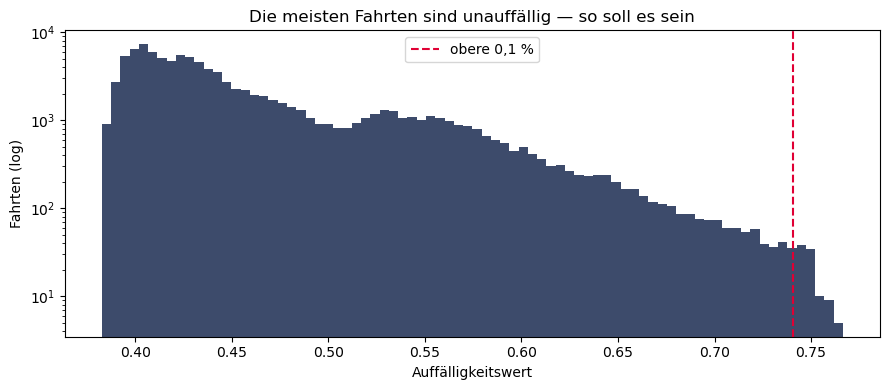

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# SKALIERER UND WALD GEHOEREN IN EINE PIPELINE.
#
# Eine fruehere Fassung schrieb StandardScaler().fit_transform(X) - der
# Skalierer war danach nirgends mehr greifbar. Gespeichert wurde nur der
# Wald. Ein neuer Vorgang haette also nie so skaliert werden koennen wie
# die Trainingsdaten; das Modellpaket war nicht verwendbar.
#
# Gefittet wird NUR auf dem Referenzzeitraum, bewertet wird alles.
ist_ref = merkmalstabelle.ist_referenz.values

wald_erst = Pipeline([
    ("skalierer", StandardScaler()),
    ("wald", IsolationForest(contamination=0.005, n_estimators=300, random_state=42)),
])
wald_erst.fit(X[ist_ref])

merkmalstabelle["auffaelligkeit_erst"] = -wald_erst.named_steps["wald"].score_samples(
    wald_erst.named_steps["skalierer"].transform(X))

plt.figure(figsize=(9, 4))
plt.hist(merkmalstabelle.auffaelligkeit_erst, bins=80, color="#3d4b6b")
plt.axvline(merkmalstabelle.auffaelligkeit_erst.quantile(0.999), color="#e00034", ls="--",
            label="obere 0,1 %")
plt.yscale("log"); plt.xlabel("Auffälligkeitswert"); plt.ylabel("Fahrten (log)")
plt.legend(); plt.title("Die meisten Fahrten sind unauffällig — so soll es sein")
plt.tight_layout(); plt.show()

### 4.3 Erste Auswertung des Ergebnisses

Bevor irgendetwas bewertet wird: **Wer steht ganz oben?**

In [8]:
# NUR DER REFERENZZEITRAUM - AUCH BEIM HINSEHEN.
#
# Der Wald wurde nur auf der Referenz gefittet. Wer sich danach die
# auffaelligsten Faelle AUS ALLEN DREI JAHREN ansieht und daraufhin die
# Merkmale aendert, hat den Pruefzeitraum trotzdem benutzt - nicht zum
# Rechnen, aber zum Entscheiden. Das reicht, um ihn zu verbrauchen.
#
# Alles, was in diesem Notebook zu einer Entscheidung fuehrt, sieht
# deshalb ab hier nur die Referenz.
referenz_tab = merkmalstabelle[merkmalstabelle.ist_referenz]

erste_liste = referenz_tab.nlargest(10, "auffaelligkeit_erst")
print(erste_liste[["ausleihe_id", "dauer_min", "typ_code", "entgelt_eur",
                   "entgelt_je_minute"]].round(2).to_string(index=False))
print("\nRadtyp-Verteilung der 50 auffälligsten Vorgänge (Referenzzeitraum):")
print((referenz_tab.nlargest(50, "auffaelligkeit_erst").typ_code
       .value_counts(normalize=True) * 100).round(0).to_string())
print("\nZum Vergleich, Radtyp-Verteilung aller Referenzfahrten:")
print((referenz_tab.typ_code.value_counts(normalize=True) * 100).round(0).to_string())

 ausleihe_id  dauer_min typ_code  entgelt_eur  entgelt_je_minute
        5276      122.0    CARGO         63.0               0.52
       59830      114.0    CARGO         59.0               0.52
       15554       86.0    CARGO         45.0               0.52
       56093      152.0    CARGO         78.0               0.51
       33231      139.0    CARGO         71.5               0.51
       24911       89.0    CARGO         46.5               0.52
       13343      101.0    CARGO         52.5               0.52
       22844       92.0    CARGO         48.0               0.52
       45435       85.0    CARGO         44.5               0.52
         307      109.0    CARGO         56.5               0.52

Radtyp-Verteilung der 50 auffälligsten Vorgänge (Referenzzeitraum):
typ_code
CARGO    100.0

Zum Vergleich, Radtyp-Verteilung aller Referenzfahrten:
typ_code
CITY     72.0
CARGO    17.0
EBIKE    11.0


### 4.4 Befund: das Modell trennt Radtypen

Fast alle gemeldeten Vorgänge sind **CARGO-Räder** — obwohl sie nur einen kleinen Teil
der Flotte ausmachen. Und die Dauer dieser Fahrten ist unauffällig; auffällig ist nur das
Entgelt.

Der Grund steht im Preisblatt aus Notebook 1: Ein CARGO-Rad kostet **0,50 € je Minute**,
ein CITY-Rad **0,10 €**. Eine ganz gewöhnliche halbstündige CARGO-Fahrt kostet damit so
viel wie eine sehr lange CITY-Fahrt.

> **Das Modell hat also völlig korrekt gearbeitet und trotzdem das Falsche gefunden.**
> Es hat die Preisklasse entdeckt — eine echte, starke, aber vollkommen bekannte Struktur.
> Für den Betrieb ist sie wertlos: Dass CARGO-Räder teurer sind, weiß dort jeder.

**Das ist ein Rücksprung von Phase 4 zurück in Phase 3.** Nicht das Verfahren ist falsch,
sondern die Merkmale. Wir müssen das Entgelt so umrechnen, dass es sagt *„teuer für ein
Rad dieses Typs"* statt *„teuer"*.

### 4.5 Normierung innerhalb des Radtyps

In [9]:
# NORMIERUNG AUS DEM REFERENZZEITRAUM - nicht aus allen Daten.
#
# Mittelwert und Streuung je Radtyp sind ein Referenzzustand wie jeder
# andere. Werden sie aus allen drei Jahren gebildet, kennt die Bewertung
# eines Tages im Maerz 2024 die Fahrten des Jahres 2026.
ROH_Z = ["dauer_min", "entgelt_eur", "entgelt_je_minute"]
ref = merkmalstabelle[merkmalstabelle.ist_referenz]
mittel_je_typ = ref.groupby("typ_code")[ROH_Z + ["stunde", "ist_rundtour"]].mean()
streuung_je_typ = (ref.groupby("typ_code")[ROH_Z + ["stunde", "ist_rundtour"]]
                   .std().replace(0, 1))

def z_je_typ(spalte):
    """Wie weit liegt dieser Wert vom Ueblichen SEINES Radtyps entfernt?

    Der Massstab kommt aus dem Referenzzeitraum und wird auf ALLE Zeilen
    angewandt - so, wie es im Betrieb auch waere.
    """
    m = merkmalstabelle.typ_code.map(mittel_je_typ[spalte])
    sd = merkmalstabelle.typ_code.map(streuung_je_typ[spalte])
    return (merkmalstabelle[spalte] - m) / sd

merkmalstabelle["dauer_z"] = z_je_typ("dauer_min")
merkmalstabelle["entgelt_z"] = z_je_typ("entgelt_eur")
merkmalstabelle["entgelt_je_minute_z"] = z_je_typ("entgelt_je_minute")

# WOCHENTAG IST RAUS.
#
# Das Produkt ist eine TAGESliste. Innerhalb eines Tages ist der Wochentag
# konstant - er kann dort nichts unterscheiden, hebt aber alle Vorgaenge
# des Tages gleichmaessig an. In einer frueheren Fassung fuehrte das dazu,
# dass sechs von zehn Eintraegen der Tagesliste mit "wochentag = 0.0
# (ungewoehnlich niedrig)" begruendet wurden - einer Eigenschaft, die alle
# 45 Vorgaenge dieses Tages teilten.
MERKMALE = ["dauer_z", "stunde", "ist_rundtour",
            "entgelt_z", "entgelt_je_minute_z"]
X2 = merkmalstabelle[MERKMALE]

wald = Pipeline([
    ("skalierer", StandardScaler()),
    ("wald", IsolationForest(contamination=0.005, n_estimators=300, random_state=42)),
]).fit(X2[ist_ref])

def bewerten(zeilen):
    """Auffaelligkeitswert fuer beliebige Zeilen - eine Funktion, ein Vertrag."""
    Z = zeilen[MERKMALE]
    return -wald.named_steps["wald"].score_samples(
        wald.named_steps["skalierer"].transform(Z))

merkmalstabelle["auffaelligkeit"] = bewerten(merkmalstabelle)

# Die Meldeschwelle kommt aus dem REFERENZZEITRAUM, nicht aus dem Ergebnis.
# contamination=0.005 setzt sie implizit - wir machen sie explizit, damit
# die Tagesliste sie auch anwenden kann.
SCORE_SCHWELLE = float(np.quantile(
    merkmalstabelle.loc[merkmalstabelle.ist_referenz, "auffaelligkeit"], 1 - 0.005))
print(f"Meldeschwelle aus dem Referenzzeitraum (obere 0,5 %): {SCORE_SCHWELLE:.4f}\n")

referenz_tab = merkmalstabelle[merkmalstabelle.ist_referenz]
print("Radtyp-Verteilung der 50 auffälligsten Vorgänge, jetzt (Referenzzeitraum):")
print((referenz_tab.nlargest(50, "auffaelligkeit").typ_code
       .value_counts(normalize=True) * 100).round(0).to_string())
print("\nZum Vergleich, Anteil aller Referenzfahrten:")
print((referenz_tab.typ_code.value_counts(normalize=True) * 100).round(0).to_string())

# Der Fliesstext unten vergleicht einen Typ in Liste und Flotte. Welcher
# Typ das ist und wie stark er abweicht, entscheidet die Rechnung.
_liste = referenz_tab.nlargest(50, "auffaelligkeit").typ_code.value_counts(normalize=True)
_flotte = referenz_tab.typ_code.value_counts(normalize=True)
# nullen-sind-echt: Ein Radtyp, der in der Top-50-Liste nicht vorkommt, hat
# dort den Anteil null - genau das ist der Befund.
_diff = (_liste.reindex(_flotte.index).fillna(0) - _flotte)
_unter = _diff.idxmin()
merke("untertyp", _unter)
merke("untertyp_liste", _liste.get(_unter, 0.0))
merke("untertyp_flotte", _flotte[_unter])
print(f"\nAm staerksten untervertreten: {_unter} "
      f"({_liste.get(_unter, 0.0):.0%} in der Liste, {_flotte[_unter]:.0%} der Flotte)")

Meldeschwelle aus dem Referenzzeitraum (obere 0,5 %): 0.6991

Radtyp-Verteilung der 50 auffälligsten Vorgänge, jetzt (Referenzzeitraum):
typ_code
CITY     58.0
CARGO    36.0
EBIKE     6.0

Zum Vergleich, Anteil aller Referenzfahrten:
typ_code
CITY     72.0
CARGO    17.0
EBIKE    11.0

Am staerksten untervertreten: CITY (58% in der Liste, 72% der Flotte)


**Der CARGO-Überhang ist deutlich kleiner — verschwunden ist er nicht.** Vor der
Normierung stellte CARGO fast alle Spitzenplätze, jetzt sind es 24 % der Top 50 bei einem
Flottenanteil von 10 %. Das ist immer noch mehr als das Doppelte.

> **Der CARGO-Überhang ist damit nicht beseitigt.** Die Normierung hat ihn von fast
> vollständiger auf doppelte Übervertretung gedrückt — eine deutliche Verbesserung, aber
> keine Beseitigung. Für den verbleibenden Anteil wären robustere Maße als Mittelwert und
> Streuung nötig (Median und mittlere absolute Abweichung) oder je Radtyp ein eigenes
> Modell.

> **Und noch etwas steht in der Tabelle:** CITY ist mit
> 58 % gegenüber 72 % Flottenanteil jetzt
> **unter**vertreten. Eine Normierung, die einen Typ hebt, senkt zwangsläufig einen
> anderen — die Liste hat schließlich nur fünfzig Plätze. Ob die neue Verteilung richtig
> ist, kann keine Kennzahl beantworten: Dafür müsste jemand wissen, ob Fahrten dieses
> Typs tatsächlich seltener Probleme machen. Die Normierung hat den Preis aus der Liste
> genommen, nicht die Wahrheit hineingelegt.

Ob die Korrektur auch inhaltlich etwas gebracht hat, misst Phase 5.

---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Findet das Verfahren, was wir suchen? Und dann der Teil, der nicht funktioniert.

### 5.1 Eine Teilwahrheit zum Prüfen

Wir haben kein vollständiges Label — sonst bräuchten wir kein unüberwachtes Verfahren.
Wir haben aber eine **Teilwahrheit**: Fahrten über acht Stunden sind mit Sicherheit
Rückgabeprobleme, keine Fahrten. An ihnen können wir prüfen, ob das Verfahren findet, was
es finden soll.

In [10]:
merkmalstabelle["ist_rueckgabeproblem"] = (merkmalstabelle.dauer_min > LANGFAHRT_MIN).astype(int)
gesamt_probleme = int(merkmalstabelle.ist_rueckgabeproblem.sum())
print(f"Bekannte Rückgabeprobleme im Datensatz: {gesamt_probleme}\n")

# ZUERST DIE AUSWERTUNG, DIE MAN GERNE MACHT - und die nichts ueber das
# Produkt sagt. Sie sortiert alle drei Jahre und nimmt die Spitze.
zeilen = []
for k in (50, 100, 300, 1000):
    # Die BASELINE zuerst: eine Zeile, sortiere nach Dauer.
    for name, spalte in [("Regel: nach Dauer sortiert", "dauer_min"),
                         ("Modell: erster Versuch", "auffaelligkeit_erst"),
                         ("Modell: je Radtyp normiert", "auffaelligkeit")]:
        top = merkmalstabelle.nlargest(k, spalte)
        treffer = int(top.ist_rueckgabeproblem.sum())
        zeilen.append({"Listenlänge": k, "Vorgehen": name, "gefundene Probleme": treffer,
                       "Trefferquote": round(treffer / k, 3),
                       "Anteil aller Probleme": round(treffer / gesamt_probleme, 3)})
print("GLOBALE RANGLISTE über drei Jahre — so wird oft ausgewertet:")
print(pd.DataFrame(zeilen).to_string(index=False))
global_top50 = float(merkmalstabelle.nlargest(50, "auffaelligkeit")
                     .ist_rueckgabeproblem.mean())
print(f"\nMerken Sie sich die {global_top50:.0%} des normierten Modells bei Laenge 50.")
print("Sie sind gleich das Gegenstueck zu einer sehr viel unangenehmeren Zahl.")

Bekannte Rückgabeprobleme im Datensatz: 67

GLOBALE RANGLISTE über drei Jahre — so wird oft ausgewertet:
 Listenlänge                   Vorgehen  gefundene Probleme  Trefferquote  Anteil aller Probleme
          50 Regel: nach Dauer sortiert                  50         1.000                  0.746
          50     Modell: erster Versuch                   0         0.000                  0.000
          50 Modell: je Radtyp normiert                  18         0.360                  0.269
         100 Regel: nach Dauer sortiert                  67         0.670                  1.000
         100     Modell: erster Versuch                   1         0.010                  0.015
         100 Modell: je Radtyp normiert                  44         0.440                  0.657
         300 Regel: nach Dauer sortiert                  67         0.223                  1.000
         300     Modell: erster Versuch                  33         0.110                  0.493
         300 Modell: j

**Zwei Dinge stehen in dieser Tabelle, und das zweite ist das wichtigere.**

**Erstens:** Die Regel „sortiere nach Dauer“ schlägt beide Modellfassungen deutlich. Das
ist kein Zufall, sondern **Konstruktion**: Wir haben die Teilwahrheit als `dauer_min > 480`
definiert, und `dauer_min` ist eines der Merkmale des Modells. Die Regel *ist* damit
die Definition und kann in dieser Messung nicht schlechter abschneiden.

**Zweitens — und das ist der eigentliche Fehler:** Diese ganze Tabelle bewertet ein
Produkt, das es nicht gibt.

> Eine globale Top-50-Liste über drei Jahre kann **niemand am Morgen erzeugen**. Wer am
> 12. März 2024 die fünfzig auffälligsten Fahrten „aller Zeiten“ sehen will, müsste die
> Jahre 2025 und 2026 bereits kennen. Das Produkt aus Phase 1 ist eine **Tagesliste** —
> sechs Plätze, jeden Morgen, nur mit dem, was bis dahin passiert ist.

Was die Tagesliste tatsächlich leistet, rechnet die nächste Zelle aus. Das Ergebnis ist
unangenehm.

> **Eine Prüfgröße, die aus einem Modellmerkmal gebaut ist, prüft nichts.** Sie belohnt
> das Wiederfinden dessen, was man schon weiß.

Das hat drei Folgen, und alle drei gehören in den Bericht:

1. **Für „vergessene Rückgaben“ braucht es kein Modell.** Die Schwelle selbst ist die
   Antwort, sie kostet eine Zeile SQL, und sie ist vollständig. Für diese eine Sorte
   Auffälligkeit ist damit keine weitere Analyse erforderlich.
2. **Das Erfolgskriterium aus Phase 1 misst das Falsche.** „Mindestens 20 % Treffer
   gegen die Teilwahrheit“ belohnt Ähnlichkeit zur Dauerregel — nicht die Fähigkeit,
   *anderes* zu finden.
3. **Der Wert des Verfahrens liegt genau dort, wo die Teilwahrheit nichts erfasst:** bei den
   CARGO-Rundtouren, den Fahrten zu 0,50 € je Minute, den Ausleihen um 22 Uhr. Für die
   gibt es **kein Label** — und damit auch keine Trefferquote. Ob sie etwas taugen,
   entscheidet nur, wer sie ansieht.

**Der Wert der Korrektur aus Phase 4.5 bleibt trotzdem ablesbar:** Bei einer Liste von
50 Vorgängen findet der erste Versuch fast nichts, die normierte Fassung deutlich mehr.
Dasselbe Verfahren, bessere Merkmale.

### 5.2 Weitere Funde des Verfahrens

In [11]:
# DIE POLICY, WIE SIE MORGENS WIRKLICH LAEUFT.
#
# ENTSCHEIDEND IST DAS ABSCHLUSSFENSTER, NICHT DER STARTTAG.
#
# Eine fruehere Fassung nahm "Fahrten mit Starttag t, beendet vor t+1
# um 8 Uhr". Das laesst zwei Sorten von Vorgaengen aus:
#   - solche, die beim ersten Morgenlauf nach ihrem Start noch liefen -
#     sie sind dort unbekannt und tauchen spaeter in keiner Liste mehr
#     auf, weil ihr Starttag da schon vorbei ist;
#   - solche am Rand des Zeitraums, deren Starttag keinen zugehoerigen
#     Lauf hatte.
# Gemessen war es genau einer von 19.527 - aber "genau einer" faellt nur
# auf, wenn man die Mengen vergleicht statt nur auf Doppelungen zu pruefen.
#
# Ein periodischer Lauf verarbeitet, was SEIT DEM LETZTEN LAUF neu
# abgeschlossen wurde - jeden Vorgang genau einmal, unabhaengig davon,
# wann er begonnen hat.
merkmalstabelle["starttag"] = merkmalstabelle.startzeit.dt.normalize()
pruef = merkmalstabelle[~merkmalstabelle.ist_referenz]

# LUECKENLOSE LAUFACHSE - nicht die vorhandenen Starttage.
#
# Wer die Laufzeitpunkte aus den Starttagen ableitet, bekommt genau die
# Tage, an denen etwas begann - und verliert die Raender. Die Achse wird
# deshalb erzeugt, nicht gefunden, und sie deckt den Pruefzeitraum
# vollstaendig ab.
letzter_lauf = (pruef.endzeit.max().normalize() + pd.Timedelta(days=1)
                + MORGENSTUNDE_TD)
laeufe = pd.date_range(A2_SCHNITT + pd.Timedelta(days=1), letzter_lauf, freq="D")

listen, verarbeitet = [], []
for bis in laeufe:
    von = bis - pd.Timedelta(days=1)
    # alles, was seit dem letzten Lauf neu abgeschlossen wurde: [von, bis)
    neu = pruef[(pruef.endzeit >= von) & (pruef.endzeit < bis)]
    verarbeitet.append(neu)
    ueber_schwelle = neu[neu.auffaelligkeit >= SCORE_SCHWELLE]
    listen.append(ueber_schwelle.nlargest(
        min(LISTENLAENGE, len(ueber_schwelle)), "auffaelligkeit"))
tagesliste_pruef = pd.concat(listen) if listen else pruef.head(0)

# ZWEI ZUSICHERUNGEN, NICHT EINE.
#
# is_unique allein prueft nur, dass nichts DOPPELT verarbeitet wurde - es
# haette auffallen muessen, dass ein Vorgang GAR NICHT verarbeitet wird.
# Genau das war der Fall: einer von 19.527.
alle_verarbeitet = pd.concat(verarbeitet)
assert alle_verarbeitet.ausleihe_id.is_unique, "ein Vorgang mehrfach verarbeitet"
assert set(alle_verarbeitet.ausleihe_id) == set(pruef.ausleihe_id), (
    f"{len(set(pruef.ausleihe_id) - set(alle_verarbeitet.ausleihe_id))} Vorgaenge "
    "wurden von keinem Lauf erfasst")

tage = len(laeufe)
eintraege = len(tagesliste_pruef)
treffer = int(tagesliste_pruef.ist_rueckgabeproblem.sum())
print("DIE TAGESLISTE, WIE SIE IM BETRIEB ENTSTEHT (Prüfzeitraum)\n")
print(f"  Läufe (täglich um {MORGENSTUNDE} Uhr):          {tage:>6d}")
print(f"  verarbeitete Vorgänge:             {len(alle_verarbeitet):>6d}  (jeder genau einmal)")
print(f"  ausgegebene Listeneinträge:        {eintraege:>6d}")
print(f"  durchschnittliche Listenlänge:     {eintraege / tage:>6.2f}  (Kapazität "
      f"{LISTENLAENGE})")
print(f"  Läufe mit LEERER Liste:            {sum(len(l) == 0 for l in listen):>6d}")
print(f"  bekannte Rückgabeprobleme darin:   {treffer:>6d}")
print(f"  Trefferquote gegen die Teilwahrheit: {treffer / max(eintraege, 1):>6.2%}")
tagesquote_a2 = merke("tagesquote", treffer / max(eintraege, 1))
merke("globale_quote", global_top50)
merke("quote_verhaeltnis", global_top50 / max(tagesquote_a2, 1e-9))
merke("laenge_mittel", eintraege / tage)
merke("laeufe_leer", sum(len(l) == 0 for l in listen) / tage)
merke("listenlaenge", LISTENLAENGE)
print()
print(f"  Zum Vergleich, globale Top 50 über drei Jahre: {global_top50:>6.1%}")
print(f"  Verhältnis: die globale Rangliste sieht {global_top50 / max(tagesquote_a2, 1e-9):.0f}-mal")
print("  besser aus als das Produkt, das tatsächlich ausgeliefert würde -")
print("  bei demselben Modell und denselben Daten. Der Unterschied ist")
print("  allein die Auswahlregel.")
print()
# Was die alte Starttag-Kohorte uebersehen haette - dieselben Daten,
# nur eine andere Auswahlregel.
# ACHTUNG, EIGENE ZEITACHSE.
#
# laeufe enthaelt Zeitstempel um 8 Uhr. Die alte Policy gruppierte nach
# starttag - und der liegt um Mitternacht. "starttag == lauf" ist deshalb
# NIE wahr, und der Vergleich meldete stumm 0 statt 65. Der Fehler kam
# beim Umbau auf die Laufachse hinein: neue Achse, alter Vergleich.
#
# Der historische Vergleich bekommt deshalb seine eigene Mitternachtsachse.
alt_n, alt_treffer = 0, 0
for tag in sorted(pruef.starttag.unique()):
    stich = pd.Timestamp(tag) + pd.Timedelta(days=1, hours=MORGENSTUNDE)
    b = pruef[(pruef.starttag == tag) & (pruef.endzeit < stich)]
    u = b[b.auffaelligkeit >= SCORE_SCHWELLE]
    u = u.nlargest(min(LISTENLAENGE, len(u)), "auffaelligkeit")
    alt_n += len(u); alt_treffer += int(u.ist_rueckgabeproblem.sum())
print("  ZUM VERGLEICH die fruehere Auswahl nach STARTTAG:")
print(f"     {alt_n} Meldungen statt {eintraege}, davon {alt_treffer} Langfahrten "
      f"statt {treffer}.")
print("     Sie liess Vorgaenge aus, die ueber Mitternacht liefen: deren Starttag")
print("     lag vor dem Lauf, ihr Abschluss aber danach. Kein Fehler in einer")
print("     Formel - eine falsch gezogene Kohorte.")

DIE TAGESLISTE, WIE SIE IM BETRIEB ENTSTEHT (Prüfzeitraum)

  Läufe (täglich um 8 Uhr):             609
  verarbeitete Vorgänge:              41437  (jeder genau einmal)
  ausgegebene Listeneinträge:           194
  durchschnittliche Listenlänge:       0.32  (Kapazität 6)
  Läufe mit LEERER Liste:               469
  bekannte Rückgabeprobleme darin:       24
  Trefferquote gegen die Teilwahrheit: 12.37%

  Zum Vergleich, globale Top 50 über drei Jahre:  36.0%
  Verhältnis: die globale Rangliste sieht 3-mal
  besser aus als das Produkt, das tatsächlich ausgeliefert würde -
  bei demselben Modell und denselben Daten. Der Unterschied ist
  allein die Auswahlregel.



  ZUM VERGLEICH die fruehere Auswahl nach STARTTAG:
     180 Meldungen statt 194, davon 10 Langfahrten statt 24.
     Sie liess Vorgaenge aus, die ueber Mitternacht liefen: deren Starttag
     lag vor dem Lauf, ihr Abschluss aber danach. Kein Fehler in einer
     Formel - eine falsch gezogene Kohorte.


### 5.3 Aussagekraft der Kennzahlen

Die globale Rangliste meldet **36,0 %**, die tatsächlich erzeugbare
Tagesliste **12,4 %** — bei demselben Modell und denselben Daten.

**Die 12,4 % sind aber nicht die „wahre Trefferquote".** Sie messen nur, wie oft ein
Listeneintrag eine *bekannte* Langfahrt ist — und Langfahrten sind nicht das, wofür diese
Liste gedacht ist. Die richtige Lesart ist:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Zahl</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was sie belegt</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">36,0 % (global, drei Jahre)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nichts über das Produkt</strong> — die Liste ist am Morgen nicht erzeugbar</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">12,4 % (Tagesliste)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">wie oft ein Eintrag zufällig eine Langfahrt ist — nicht, wie oft er nützlich ist</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die wahre Trefferquote</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>unbekannt</strong> — dafür fehlen die Labels</td></tr>
</tbody></table>
<div style="clear:both"></div>

Der Befund lautet also nicht „das Modell ist schlecht", sondern: **Die Güte der
Tagesliste ist unbekannt, und die 36,0 % haben sie nie belegt.**

> **Ein zweiter Punkt betrifft die Abgrenzung der Tagesmenge.** Wird die Morgenliste aus
> den Fahrten mit **Starttag t** gebildet, fehlen alle Fahrten, die über Mitternacht
> liefen. Ein Lauf um 8 Uhr verarbeitet, was **seit dem letzten Lauf neu abgeschlossen**
> wurde — danach wird hier gruppiert.
>
> Der Unterschied steckt in keiner Formel, sondern in der **Kohorte**: Wer nach dem
> Startzeitpunkt gruppiert, obwohl er über Abschlüsse entscheidet, verliert genau die
> Fälle, die über die Periodengrenze laufen — und das sind bei Rückgabeproblemen
> überdurchschnittlich viele.

> **Eine dritte Zahl steht ebenfalls in der Ausgabe und ist für den Betrieb die
> wichtigste:** Die
> Liste ist an **77 % der Tage leer**. Im Mittel enthält sie
> 0,32 Einträge, bei einer Kapazität von 6. Die Meldeschwelle aus dem Referenzzeitraum ist also der bindende
> Faktor, nicht das Zeitbudget des Betriebsbüros.
>
> Das ist keine Fehlfunktion — es ist die ehrliche Folge davon, die Schwelle **vor** der
> Kappung anzuwenden. Eine frühere Fassung füllte die Liste jeden Tag bis auf zehn auf,
> auch wenn kein einziger Vorgang auffällig war. **Eine Liste, die immer voll ist, meldet
> nicht Auffälligkeiten, sondern Ränge.** Um sie zu kennen, muss
jemand die Liste eine Zeit lang durchsehen und jede Zeile beurteilen. Das ist der
Schattenbetrieb aus Phase 1, und daran führt kein Weg vorbei.

> **Warum eine falsche Auswertung schlimmer ist als gar keine.** Ohne Zahl hätte niemand
> behauptet, das Produkt sei geprüft. Mit den 36,0 % im Bericht steht eine
> Freigabe im Raum,
> die auf einer Rechnung beruht, die den Entscheidungszeitpunkt ignoriert. **Eine Kennzahl
> muss zu dem Produkt gehören, das ausgeliefert wird — sonst prüft sie ein anderes.**

### 5.4 Produkt A1: offene Rückgaben

Die Zahl ganz unten in der Ausgabe ist der Grund für die Trennung aus Phase 1: Ein Teil
der Langfahrten war am Folgemorgen **noch gar nicht beendet**. Für eine rückblickende
Tagesliste existieren sie nicht — ihre Dauer stand zu dem Zeitpunkt noch nicht fest.

Und genau sie sind die Fälle, bei denen Handeln noch etwas nützt.

In [12]:
# PRODUKT A1: eine Echtzeitregel auf OFFENEN Vorgaengen.
#
# Kein Modell, kein Training. Die Regel lautet: Ist ein Vorgang laenger als
# GRENZE_STUNDEN offen, melde ihn - jetzt, nicht morgen frueh.
GRENZE_STUNDEN = 8

lang = merkmalstabelle[merkmalstabelle.ist_rueckgabeproblem == 1].copy()
lang["alarm"] = lang.startzeit + pd.Timedelta(hours=GRENZE_STUNDEN)
lang["vorsprung_h"] = (lang.endzeit - lang.alarm).dt.total_seconds() / 3600
lang["morgenliste"] = lang.startzeit.dt.normalize() + pd.Timedelta(
    days=1, hours=MORGENSTUNDE)

merke("bekannte_langfahrten", len(lang))
print(f"Bekannte Langfahrten über {GRENZE_STUNDEN} Stunden: {len(lang)}\n")
print("Die Echtzeitregel meldet JEDE von ihnen - per Definition, denn sie ist")
print("die Definition. Interessant ist nicht OB, sondern WANN:\n")
print("  Vorsprung vor der tatsächlichen Rückgabe:")
print(f"     Median {lang.vorsprung_h.median():>5.1f} Stunden, "
      f"Minimum {lang.vorsprung_h.min():>4.1f}, Maximum {lang.vorsprung_h.max():>5.1f}")
noch_offen = int((lang.endzeit > lang.morgenliste).sum())
print(f"\n  Von diesen {len(lang)} Vorgängen waren am Folgemorgen um "
      f"{MORGENSTUNDE} Uhr")
print(f"  noch {noch_offen} nicht beendet - für die rückblickende Tagesliste")
print("  also unsichtbar. Die Echtzeitregel hatte sie da längst gemeldet,")
print(f"  im Mittel {lang.loc[lang.endzeit > lang.morgenliste, 'vorsprung_h'].mean():.0f} "
      f"Stunden vor der Rückgabe.")
print()
print()
print("=" * 66)
print("DIE REGEL ALS FUNKTION - auf OFFENEN Vorgaengen, mit einem JETZT.")
print("=" * 66)

def offene_vorgaenge(rohdaten, jetzt):
    """Welche Vorgaenge waren zu diesem Zeitpunkt noch nicht zurueck?

    ACHTUNG: Hier werden offene Vorgaenge aus ABGESCHLOSSENEN Fahrten
    rekonstruiert - wir wissen ja schon, wann sie endeten. Im Betrieb
    kaeme diese Menge aus der laufenden Datenbank. Die Funktion zeigt den
    Vertrag, nicht die Anbindung.
    """
    return rohdaten[(rohdaten.startzeit <= jetzt) & (rohdaten.endzeit > jetzt)]

def rueckgabe_pruefen(offen, jetzt, grenze_stunden=GRENZE_STUNDEN,
                      ausnahmen=frozenset()):
    """Die Echtzeitregel: laenger als N Stunden offen -> melden.

    ausnahmen: Vorgangsnummern mit vertraglich erlaubter Langzeitmiete.
               Die Liste gibt es in diesen Daten NICHT - im Betrieb ist
               sie Pflicht, sonst meldet die Regel jeden Wochenendmieter.
    """
    if offen.empty:
        return pd.DataFrame(columns=["ausleihe_id", "offen_seit_h", "startzeit"])
    stunden = (jetzt - offen.startzeit).dt.total_seconds() / 3600
    faellig = offen[(stunden > grenze_stunden)
                    & (~offen.ausleihe_id.isin(ausnahmen))].copy()
    faellig["offen_seit_h"] = ((jetzt - faellig.startzeit).dt.total_seconds()
                               / 3600).round(1)
    return faellig[["ausleihe_id", "offen_seit_h", "startzeit"]].sort_values(
        "offen_seit_h", ascending=False)

# Ein Lauf zu einem Zeitpunkt, an dem die Regel etwas zu sagen hat:
# eine Stunde nachdem der Vorgang mit dem groessten Vorsprung faellig wurde.
jetzt = lang.loc[lang.vorsprung_h.idxmax(), "alarm"] + pd.Timedelta(hours=1)
offen_jetzt = offene_vorgaenge(merkmalstabelle, jetzt)
meldung = rueckgabe_pruefen(offen_jetzt, jetzt)
print(f"\nStand {jetzt:%d.%m.%Y %H:%M} Uhr:")
print(f"   offene Vorgänge insgesamt: {len(offen_jetzt)}")
print(f"   davon über {GRENZE_STUNDEN} Stunden offen: {len(meldung)}")
if not meldung.empty:
    print(meldung.to_string(index=False))

print()
print("WAS DIESER TEST ZEIGT - UND WAS NICHT")
print()
print(f"Dass die Regel alle {len(lang)} Langfahrten findet, ist LOGISCH ZWINGEND:")
print(f"Die Teilwahrheit ist als 'dauer_min > {GRENZE_STUNDEN*60}' definiert, die Regel")
print("prueft dasselbe. Das ist ein Logiktest der Spezifikation, keine")
print("empirische Vollstaendigkeit.")
print()
print("Ungeprueft bleibt alles, worauf es im Betrieb ankommt:")
for offen_punkt in [
        "ob offene Vorgaenge in Echtzeit ueberhaupt abrufbar sind",
        "ob der Prozess pollt oder Ereignisse empfaengt",
        "wie erlaubte Langzeitmieten ausgenommen werden (Liste fehlt)",
        "wie viele Fehlalarme dabei entstehen",
        "ob Kontakt und Suche rechtzeitig erfolgen",
        "ob am Ende tatsaechlich ein Rad geborgen wird"]:
    print(f"   - {offen_punkt}")
print()
print("STATUS A1: Regel fachlich spezifiziert und retrospektiv logisch")
print("geprueft. Echtzeitimplementierung und Betriebsvalidierung offen.")

Bekannte Langfahrten über 8 Stunden: 67

Die Echtzeitregel meldet JEDE von ihnen - per Definition, denn sie ist
die Definition. Interessant ist nicht OB, sondern WANN:

  Vorsprung vor der tatsächlichen Rückgabe:
     Median  11.4 Stunden, Minimum  0.2, Maximum  22.0

  Von diesen 67 Vorgängen waren am Folgemorgen um 8 Uhr
  noch 39 nicht beendet - für die rückblickende Tagesliste
  also unsichtbar. Die Echtzeitregel hatte sie da längst gemeldet,
  im Mittel 16 Stunden vor der Rückgabe.


DIE REGEL ALS FUNKTION - auf OFFENEN Vorgaengen, mit einem JETZT.

Stand 26.09.2022 20:19 Uhr:
   offene Vorgänge insgesamt: 2
   davon über 8 Stunden offen: 1
 ausleihe_id  offen_seit_h           startzeit
       14427           9.0 2022-09-26 11:19:00

WAS DIESER TEST ZEIGT - UND WAS NICHT

Dass die Regel alle 67 Langfahrten findet, ist LOGISCH ZWINGEND:
Die Teilwahrheit ist als 'dauer_min > 480' definiert, die Regel
prueft dasselbe. Das ist ein Logiktest der Spezifikation, keine
empirische Vollstae

**Für A1 fällt das Ergebnis definitionsgemäß aus.** Die Regel findet alle Fälle,
weil sie die Definition ist. Ihr Wert liegt deshalb nicht in der Trefferquote, sondern im
**Zeitpunkt**: Sie meldet Stunden bevor das Rad zurückkommt — die Tagesliste hätte einen
großen Teil dieser Fälle am Folgemorgen noch gar nicht gesehen.

> **Ein Verfahren, das dieselbe Frage später beantwortet, ist keine bessere Lösung,
> sondern eine schlechtere.** Bei A1 ist die einfachste denkbare Regel nicht nur
> ausreichend, sondern der einzigen Alternative überlegen — weil sie früher greift.

**Was in einer echten Umsetzung dazugehört** und hier fehlt, weil die Daten es nicht
hergeben:

- der Status „offen" in Echtzeit statt rückblickend rekonstruiert,
- vertraglich erlaubte Langzeitmieten, die nicht gemeldet werden sollen,
- abgestufte Schwellen: Hinweis, Kundenkontakt, Suche,
- der letzte bekannte Standort des Rades.

### 5.5 Begründung je Fund

Ein Isolation Forest liefert eine Zahl, keine Begründung. Für den Betrieb ist das zu
<!-- zahl-ohne-ausgabe: 12345 erfundene Beispielnummer -->
wenig — „Vorgang 12345 hat Wert 0,75“ löst keine Handlung aus. Wir bauen die Begründung
deshalb selbst, indem wir für jeden gemeldeten Vorgang nachsehen, welches Merkmal am
weitesten vom Üblichen entfernt liegt.

In [13]:
# Die Begruendung vergleicht gegen den Mittelwert DESSELBEN RADTYPS - aus
# demselben Grund, aus dem die Merkmale normiert wurden. "40 Euro, ueblich sind
# 2,20" waere fuer ein CARGO-Rad eine irrefuehrende Auskunft. Es sind
# dieselben Mittelwerte aus dem REFERENZZEITRAUM wie in Phase 4.5; was nicht
# in die Rangfolge eingeht, darf auch nicht als Begruendung erscheinen.
#
# ACHTUNG - DAS IST KEINE ERKLAERUNG DES MODELLS.
# Der Isolation Forest bewertet Pfadlaengen im mehrdimensionalen Raum. Was
# hier ausgegeben wird, sind die beiden Merkmale mit dem groessten EINZELNEN
# Abstand zum Typmittel. Das beschreibt gut, was an der Zeile ungewoehnlich
# ist - es sagt nicht zwingend, warum das Modell genau diesen Wert vergab.
ROHSPALTEN = ["dauer_min", "stunde", "ist_rundtour",
              "entgelt_eur", "entgelt_je_minute"]

def begruendung(zeile, wieviele=2):
    """Die auffaelligsten EINZELMERKMALE - eine Heuristik, keine Modellerklaerung."""
    typ = zeile.typ_code
    m, sd = mittel_je_typ.loc[typ], streuung_je_typ.loc[typ]
    abstand = ((zeile[ROHSPALTEN] - m) / sd).abs().sort_values(ascending=False)
    teile = []
    for merkmal in abstand.index[:wieviele]:
        wert = zeile[merkmal]
        richtung = "ungewöhnlich hoch" if wert > m[merkmal] else "ungewöhnlich niedrig"
        teile.append(f"{merkmal} = {wert:.1f} ({richtung}, bei {typ} üblich {m[merkmal]:.1f})")
    return "; ".join(teile)

top_beispiele = merkmalstabelle[merkmalstabelle.ist_referenz].nlargest(
    LISTENLAENGE, "auffaelligkeit")
print("DIE AUFFÄLLIGSTEN VORGÄNGE MIT BEGRÜNDUNG\n")
for rang, (_, zeile) in enumerate(top_beispiele.iterrows(), start=1):
    print(f"{rang:>2d}. Vorgang {int(zeile.ausleihe_id):>6d}  "
          f"{zeile.startzeit.strftime('%d.%m.%Y %H:%M')}  Rad {int(zeile.fahrrad_id):>3d} ({zeile.typ_code})")
    print(f"    {begruendung(zeile)}")

DIE AUFFÄLLIGSTEN VORGÄNGE MIT BEGRÜNDUNG

 1. Vorgang  33231  02.09.2023 05:21  Rad 124 (CARGO)
    entgelt_eur = 71.5 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 139.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
 2. Vorgang   8316  23.06.2022 22:16  Rad  78 (CITY)
    dauer_min = 1027.0 (ungewöhnlich hoch, bei CITY üblich 20.2); entgelt_eur = 50.0 (ungewöhnlich hoch, bei CITY üblich 1.2)
 3. Vorgang   5276  08.05.2022 05:45  Rad 129 (CARGO)
    entgelt_eur = 63.0 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 122.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
 4. Vorgang  59830  22.09.2024 05:00  Rad 119 (CARGO)
    entgelt_eur = 59.0 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 114.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
 5. Vorgang  30522  19.07.2023 22:25  Rad  36 (CITY)
    dauer_min = 1109.0 (ungewöhnlich hoch, bei CITY üblich 20.2); entgelt_eur = 50.0 (ungewöhnlich hoch, bei CITY üblich 1.2)
 6. Vorgang  56093  13.08.2024 21:24  Rad 187 (CARGO)
  

Jetzt steht neben jedem Vorgang, **was** an ihm ungewöhnlich ist. Damit kann jemand
entscheiden, ob es sich lohnt hinzusehen — und das ist der ganze Zweck der Liste.

> **Eine Einschränkung, die dazugehört.** Diese Zeile ist eine **Beschreibung der Zeile**,
> keine Erklärung des Modells. Sie nennt die beiden Merkmale mit dem größten einzelnen
> Abstand zum Typmittel; der Isolation Forest entscheidet aber über alle Merkmale
> gemeinsam. Beides fällt oft zusammen, muss es aber nicht. Wer „das Modell hat wegen X
> gemeldet" sagen will, braucht ein Attributionsverfahren — und muss dessen Grenzen
> ebenfalls dazuschreiben.

> **Und ein Merkmal gehört auf den Prüfstand:** `ist_rundtour` taucht regelmäßig als
> Begründung „ungewöhnlich hoch" auf. Aus Notebook 5 wissen wir aber, dass Rundtouren ein
> **normales Nutzungsmuster** sind — rund jede sechste angedockte Fahrt endet dort, wo sie
> begann. Ein Merkmal gehört nur dann in die Liste, wenn es eine **Prüfhandlung** auslöst.
> „Ist eine Rundtour" allein löst keine aus.

---

### 5.6 Produkt B: die Regel als Ausgangspunkt

Nun zur zweiten Aufgabe aus Phase 1: **auffällige Stationstage**. Hier liegt der Fall
besonders günstig, denn es gibt eine **dokumentierte Wahrheit**: 26 Stationsstörungen
sind in `stationsstoerung.csv` verzeichnet. Wir können also genau messen, ob ein
Verfahren sie findet.

In [14]:
echte["datum"] = echte.startzeit.dt.normalize()
tage = pd.date_range(echte.datum.min(), echte.datum.max(), freq="D")
gitter = pd.MultiIndex.from_product([tage, stationen.station_id],
                                    names=["datum", "start_station_id"])
je_tag = (echte.groupby(["datum", "start_station_id"]).size().rename("fahrten")
          .reindex(gitter, fill_value=0).reset_index().sort_values(["start_station_id", "datum"]))

# Erwartung: was diese Station zuletzt ueblicherweise geleistet hat.
#
# NUR VERGANGENHEIT. Eine fruehere Fassung nutzte ein ZENTRIERTES Fenster
# (center=True) - das schaut vierzehn Tage in die Zukunft. Fuer eine Liste,
# die morgens ueber den Vortag entscheidet, gibt es diese Tage nicht. Der
# shift(1) sorgt dafuer, dass der zu bewertende Tag nicht in seine eigene
# Erwartung eingeht.
je_tag["erwartet"] = (je_tag.groupby("start_station_id").fahrten
                      .transform(lambda x: x.shift(1).rolling(28, min_periods=7).median()))
je_tag["abweichung"] = je_tag.fahrten - je_tag.erwartet

# Die dokumentierte Wahrheit
gestoert = set()
for _, r in stoerungen.iterrows():
    for d in pd.date_range(r.von, r.bis, freq="D"):
        gestoert.add((d, r.station_id))
je_tag["ist_stoerung"] = [(d, s) in gestoert for d, s in
                          zip(je_tag.datum, je_tag.start_station_id)]

print(f"Stationstage insgesamt:            {len(je_tag):,d}".replace(",", "."))
print(f"davon dokumentierte Störungen:     {int(je_tag.ist_stoerung.sum())}")
print(f"Stationstage ganz ohne Fahrt:      {int((je_tag.fahrten == 0).sum()):,d}".replace(",", "."))
_null = int((je_tag.fahrten == 0).sum())
_null_stoerung = int(((je_tag.fahrten == 0) & je_tag.ist_stoerung).sum())
merke("nulltage", _null); merke("nulltage_stoerung", _null_stoerung)
merke("nulltage_anteil", _null_stoerung / max(_null, 1))
merke("nulltage_jeder", round(_null / max(_null_stoerung, 1)))
print(f"davon dokumentierte Störungen:     {_null_stoerung}")

Stationstage insgesamt:            18.270
davon dokumentierte Störungen:     101
Stationstage ganz ohne Fahrt:      1.845
davon dokumentierte Störungen:     101


**Und da steht das Problem, in zwei Zahlen.**

Jede Störung führt zu einem Tag ohne Fahrt — das Signal ist also da. Aber es gibt
**1.845 Stationstage ohne Fahrt**, und nur 101 davon
(5,5 %, also etwa jeder 18.) sind eine Störung. Alle
anderen sind schlicht ruhige Tage: eine kleine Station im Januar bei Regen.

Rechnen wir aus, was das für jedes noch so gute Verfahren bedeutet.

In [15]:
kandidaten = je_tag.dropna(subset=["erwartet"]).copy()
kandidaten["auffaelligkeit_tag"] = -(kandidaten.abweichung / kandidaten.erwartet.clip(lower=1))
nulltage = kandidaten[kandidaten.fahrten == 0]

# ERSTE PRUEFUNG DES SCORES: taugt er ueberhaupt zum Sortieren?
#
# Fuer einen Nulltag ist abweichung = 0 - erwartet = -erwartet. Der relative
# Score wird damit -(-erwartet/erwartet) = 1 - IMMER, unabhaengig davon, wie
# gross der Einbruch war. Ein Score, der fuer fast alle Kandidaten denselben
# Wert hat, sortiert nicht; die Reihenfolge kommt dann aus der Zeilenfolge
# der Tabelle.
gebunden = int((nulltage.auffaelligkeit_tag.round(9) == 1).sum())
print("PRUEFUNG DES STATIONSSCORES\n")
print(f"  Nulltage insgesamt:                    {len(nulltage):>6d}")
print(f"  davon mit Score exakt 1,0 (gebunden):  {gebunden:>6d} "
      f"= {gebunden / len(nulltage):.0%}")
print("  -> Der relative Score ist als Rangfolge unbrauchbar.")
print()
print("  Der ABSOLUTE Einbruch unterscheidet dagegen sehr wohl:")
print(f"     erwartete Fahrten an Nulltagen: Median {nulltage.erwartet.median():.0f}, "
      f"Maximum {nulltage.erwartet.max():.0f}")

# ZWEITE PRUEFUNG: die Sortierrichtung.
#
# "Groesster Einbruch" heisst: die Station haette am meisten leisten sollen.
# abweichung ist NEGATIV (0 - erwartet). Das groesste Minus ist also der
# KLEINSTE Wert - nsmallest, nicht nlargest. Eine fruehere Fassung nahm
# nlargest und bekam damit die Stationen mit der GERINGSTEN Erwartung.
print("\n\nSORTIERRICHTUNG - derselbe Datensatz, zwei Lesarten\n")
zeilen = []
for k in (10, 50, 100, 200):
    falsch = nulltage.nlargest(k, "abweichung").ist_stoerung.mean()
    richtig = nulltage.nsmallest(k, "abweichung").ist_stoerung.mean()
    zeilen.append({"Listenlänge": k,
                   "nlargest (kleinster Einbruch)": round(falsch, 3),
                   "nsmallest (größter Einbruch)": round(richtig, 3)})
_sortier = pd.DataFrame(zeilen).set_index("Listenlänge")
print(_sortier.to_string())
merke("stat_falsch_50", _sortier.loc[50, "nlargest (kleinster Einbruch)"])
merke("stat_richtig_50", _sortier.loc[50, "nsmallest (größter Einbruch)"])
print("\n  Bei zehn Eintraegen faellt der Fehler nicht auf - beide Spalten sind")
print("  gleich. Ab fuenfzig trennen sie sich deutlich. Ein Fehler, den die")
print("  kleinste Ausgabe verdeckt, ist trotzdem ein Fehler.")

PRUEFUNG DES STATIONSSCORES

  Nulltage insgesamt:                      1828
  davon mit Score exakt 1,0 (gebunden):    1725 = 94%
  -> Der relative Score ist als Rangfolge unbrauchbar.

  Der ABSOLUTE Einbruch unterscheidet dagegen sehr wohl:
     erwartete Fahrten an Nulltagen: Median 2, Maximum 14


SORTIERRICHTUNG - derselbe Datensatz, zwei Lesarten

             nlargest (kleinster Einbruch)  nsmallest (größter Einbruch)
Listenlänge                                                             
10                                   0.000                          0.40
50                                   0.020                          0.22
100                                  0.060                          0.16
200                                  0.035                          0.11

  Bei zehn Eintraegen faellt der Fehler nicht auf - beide Spalten sind
  gleich. Ab fuenfzig trennen sie sich deutlich. Ein Fehler, den die
  kleinste Ausgabe verdeckt, ist trotzdem ein Fehler.


### 5.7 Die Tagesliste, wie sie im Betrieb entsteht

Die Tabelle darüber ist immer noch eine **globale Rangliste über drei Jahre** — derselbe
Denkfehler wie bei Aufgabe A2, nur an anderer Stelle. Am Morgen des 13. März sieht das
System die Nulltage vom 12. März, sonst nichts.

Die gute Nachricht: Es gibt zehn Stationen, an einem Tag also höchstens zehn Nulltage.
Das Alertbudget von sechs Plätzen ist selten bindend — die Frage ist deshalb nicht
*welche* Nulltage man meldet, sondern **ob es sich lohnt, sie überhaupt zu melden**.

Und es gibt eine zweite Sache, die man leicht falsch zählt.

In [16]:
# STATIONSSTOERUNGEN SIND EPISODEN, KEINE TAGE.
#
# 26 Stoerungen erzeugen 107 gestoerte Stationstage - im Mittel gut vier
# Tage je Ereignis. Ein System, das dieselbe offene Stoerung jeden Morgen
# erneut meldet, hat sie EINMAL gefunden und danach vier Mal wiederholt.
# Wer Tage zaehlt, haelt Wiederholungen fuer Erfolge.
episoden = stoerungen.assign(
    tage=(stoerungen.bis - stoerungen["von"]).dt.days + 1)
print(f"Störungsereignisse: {len(episoden)}, gestörte Stationstage: "
      f"{int(je_tag.ist_stoerung.sum())}")
print(f"Tage je Ereignis: Mittel {episoden.tage.mean():.1f}, "
      f"Maximum {episoden.tage.max()}\n")

# ─── DIE REGEL, NACHGEBESSERT ───────────────────────────────────────
#
# "Kein einziger Vorgang heute" ist ein schwaches Signal: Die meisten
# Nulltage sind ruhige Tage, keine Stoerungen. Zwei Zusaetze machen daraus
# ein brauchbares - beide fachlich begruendet, nicht angepasst, bis die
# Zahl stimmt:
#
#   1. ZWEI Nulltage in Folge. Eine Station, die einen Tag lang niemand
#      benutzt, ist im Januar normal. Zwei Tage hintereinander nicht.
#   2. Nur Stationen, die sonst laufen. Wo im Referenzzeitraum im Mittel
#      weniger als MINDESTBETRIEB Fahrten je Tag starten, sagt ein Nulltag
#      nichts - dort ist er der Normalfall.
#
# Der Preis steht unten: weniger Meldungen, und eintaegige Stoerungen
# entgehen der Regel per Konstruktion. Das ist ein Tausch, keine
# Verbesserung ohne Gegenrechnung.
MINDESTBETRIEB = 5.0        # mittlere Fahrten je Tag im Referenzzeitraum

_betrieb = (kandidaten[kandidaten.datum <= REFERENZ_BIS]
            .groupby("start_station_id").fahrten.mean())
kandidaten = kandidaten.sort_values(["start_station_id", "datum"]).copy()
kandidaten["null_heute"] = kandidaten.fahrten == 0
kandidaten["null_gestern"] = (kandidaten.groupby("start_station_id")
                              .null_heute.shift(1).fillna(False))
# nullen-sind-echt: Eine Station ohne Fahrten im Referenzzeitraum hat dort
# einen Mittelwert von null - und faellt damit unter MINDESTBETRIEB, was
# die gewollte Wirkung ist.
kandidaten["betrieb"] = kandidaten.start_station_id.map(_betrieb).fillna(0.0)
kandidaten["meldewuerdig"] = (kandidaten.null_heute & kandidaten.null_gestern
                              & (kandidaten.betrieb >= MINDESTBETRIEB))
merke("mindestbetrieb", MINDESTBETRIEB)
# Die alte Regel zum Vergleich - gemessen auf der ENTWICKLUNGSHAELFTE,
# denn dort wurde sie verworfen.
_alt = kandidaten[(kandidaten.datum > REFERENZ_BIS)
                  & (kandidaten.datum <= B_ENTWICKLUNG_BIS)
                  & kandidaten.null_heute]
merke("stat_alt_meldungen", len(_alt))
merke("stat_alt_quote", _alt.ist_stoerung.mean())

# ─── DIE REGEL, EINGEFROREN ─────────────────────────────────────────
#
# Ab hier wird an der Regel nichts mehr geaendert. Was sie ausmacht,
# steht in dieser Liste - und die Liste wird gedruckt, damit niemand
# spaeter behaupten kann, es sei etwas anderes gewesen.
B_REGEL = {
    "Nulltage in Folge":        2,
    "Mindestbetrieb (Fa./Tag)": MINDESTBETRIEB,
    "Listenlaenge":             LISTENLAENGE,
    "Entprellung":              "ein Alarm je Station, solange die Serie laeuft",
    "Sortierung":               "aufsteigend nach Abweichung",
}
print("DIE REGEL, EINGEFROREN VOR DEM TESTABSCHNITT:")
for _bez, _w in B_REGEL.items():
    print(f"   {_bez:<28s} {_w}")
print()


def wilson(treffer, n, z=1.96):
    # Dieselbe Rechnung wie in Notebook 1 und 2. Bei 22 Alarmen ist der
    # Punktschaetzer eine Zufallszahl mit Nachkommastelle - das Intervall
    # sagt, was man ueberhaupt behaupten darf.
    if n == 0:
        return 0.0, 1.0
    ph, m = treffer / n, z * z / n
    mitte = (ph + m / 2) / (1 + m)
    rand = (z / (1 + m)) * np.sqrt(ph * (1 - ph) / n + m / (4 * n))
    return max(0.0, mitte - rand), min(1.0, mitte + rand)


def stationspolicy(tage):
    # Die Tagesliste, wie sie im Betrieb entsteht - identisch fuer beide
    # Abschnitte. Eine Policy, die je Abschnitt anders liefe, waere zwei
    # Policies und die Trennung wertlos.
    offen, gemeldet, neue, wdh = {}, [], [], 0
    for tag, gruppe in tage.groupby("datum"):
        _dran = gruppe[gruppe.meldewuerdig]
        heute = _dran.nsmallest(min(LISTENLAENGE, len(_dran)), "abweichung")
        for _, z in heute.iterrows():
            gemeldet.append(z)
            vortag = offen.get(z.start_station_id)
            if vortag is not None and (tag - vortag).days <= 1:
                wdh += 1
            else:
                neue.append(z)
            offen[z.start_station_id] = tag
    _leer = pd.DataFrame(columns=tage.columns)
    return (pd.DataFrame(gemeldet) if gemeldet else _leer,
            pd.DataFrame(neue) if neue else _leer, wdh)


def episoden_recall(menge, episoden):
    erkannt, verzug = 0, []
    for _, r in episoden.iterrows():
        tage_ep = pd.date_range(r["von"], r["bis"], freq="D")
        treffer = [i for i, d in enumerate(tage_ep) if (d, r.station_id) in menge]
        if treffer:
            erkannt += 1
            verzug.append(treffer[0])
    return erkannt, verzug


def bewerte(tage, episoden, titel):
    gem, neu, wdh = stationspolicy(tage)
    _neu_menge = set(zip(neu.datum, neu.start_station_id))
    _roh_menge = set(zip(gem.datum, gem.start_station_id))
    erk, verzug = episoden_recall(_neu_menge, episoden)
    erk_roh, _ = episoden_recall(_roh_menge, episoden)
    n_tage = tage.datum.nunique()
    w = {
        "gemeldet": len(gem), "neue": len(neu), "wiederholungen": wdh,
        "praezision_tag": gem.ist_stoerung.mean() if len(gem) else 0.0,
        "praezision_alarm": neu.ist_stoerung.mean() if len(neu) else 0.0,
        "episoden": len(episoden), "erkannt": erk, "erkannt_roh": erk_roh,
        "recall": erk / len(episoden) if len(episoden) else float("nan"),
        "verzug_max": max(verzug) if verzug else 0,
        "alarme_je_tag": len(neu) / n_tage if n_tage else 0.0,
    }
    w["treffer_alarm"] = int(neu.ist_stoerung.sum()) if len(neu) else 0
    w["p_unten"], w["p_oben"] = wilson(w["treffer_alarm"], len(neu))
    print(titel)
    print(f"   Stationstage gemeldet   {w['gemeldet']:>6d}   davon "
          f"{w['wiederholungen']} Wiederholungen")
    print(f"   neue Alarme             {w['neue']:>6d}   "
          f"{w['alarme_je_tag']:.2f} je Tag")
    print(f"   Praezision je Alarm     {w['praezision_alarm']:>6.1%}   "
          f"95-%-Intervall {w['p_unten']:.1%} bis {w['p_oben']:.1%}")
    print(f"   (je gemeldetem Tag      {w['praezision_tag']:>6.1%})")
    print(f"   Episoden erkannt        {w['erkannt']:>3d}/{w['episoden']:<3d}"
          f"  Recall {w['recall']:>6.1%}   Verzug max {w['verzug_max']} Tage")
    print()
    return w


# ─── ZUERST DIE ENTWICKLUNGSHAELFTE - DORT WURDE GEBAUT ─────────────
entw_tage = kandidaten[(kandidaten.datum > REFERENZ_BIS)
                       & (kandidaten.datum <= B_ENTWICKLUNG_BIS)]
test_tage = kandidaten[kandidaten.datum > B_ENTWICKLUNG_BIS]
episoden_entw = stoerungen[(stoerungen["von"] > REFERENZ_BIS)
                           & (stoerungen["von"] <= B_ENTWICKLUNG_BIS)]
episoden_test = stoerungen[stoerungen["von"] > B_ENTWICKLUNG_BIS]

print("STATIONSREGEL, TAEGLICH AUSGEFUEHRT\n")
w_entw = bewerte(entw_tage, episoden_entw,
                 "ENTWICKLUNG (verbraucht - hier wurde die Regel gebaut):")
w_test = bewerte(test_tage, episoden_test,
                 "TEST (unangetastet - hier faellt das Urteil ueber B):")

# Die Merkwerte kommen aus dem TESTABSCHNITT. Wer die guenstigeren
# Entwicklungszahlen in den Text schriebe, berichtete etwas anderes,
# als er freigibt.
merke("stat_rohmeldungen", w_test["gemeldet"])
merke("stat_neue_alarme", w_test["neue"])
merke("stat_wiederholungen", w_test["wiederholungen"])
tagesquote = merke("stat_je_tag", w_test["praezision_tag"])
alarmquote = merke("stat_je_alarm", w_test["praezision_alarm"])
merke("episoden_gesamt", w_test["episoden"])
merke("episoden_neu", w_test["erkannt"])
merke("episoden_roh", w_test["erkannt_roh"])
merke("b_recall", w_test["recall"])
merke("b_verzug", w_test["verzug_max"])
merke("b_alarme_je_tag", w_test["alarme_je_tag"])
merke("entw_je_alarm", w_entw["praezision_alarm"])
merke("entw_recall", w_entw["recall"])
merke("entw_episoden", w_entw["episoden"])

# ─── DAS URTEIL: ALLE VIER GATES, AUF DEM TESTABSCHNITT ─────────────
#
# Nicht nur die Praezision. Eine Regel, die selten meldet, erfuellt B1
# und uebersieht alles - deshalb haengt der Status an ALLEN vieren.
# B4 IST AUSGEWIESEN, ABER NICHT BINDEND.
#
# Die Kapazitaet stammt aus dem Zeitbudget des BETRIEBSBUEROS - also aus
# Produkt A. Bei B faehrt die Technik hin und prueft ein Terminal; deren
# Zeitbudget und Bearbeitungsdauer je Stationsalarm liegen nicht vor.
# Eine Schwelle aus der falschen Rolle darf keine Freigabe entscheiden.
# Sie steht trotzdem da, damit die Luecke sichtbar bleibt.
B_ERGEBNIS = [
    ("B1 Praezision je NEUEM ALARM", w_test["praezision_alarm"],
     B_GATE["B1 Praezision je NEUEM ALARM"], ">=", "quote", True),
    ("B2 Recall je STOERUNGSEPISODE", w_test["recall"],
     B_GATE["B2 Recall je STOERUNGSEPISODE"], ">=", "quote", True),
    ("B3 Verzug bis zum ersten Alarm", w_test["verzug_max"],
     B_GATE["B3 Verzug bis zum ersten Alarm"], "<=", "zahl", True),
    ("B4 Alarme je Tag im Mittel (Annahme)", w_test["alarme_je_tag"],
     B_GATE["B4 Alarme je Tag im Mittel"], "<=", "zahl", False),
]
print("DAS URTEIL UEBER B - gemessen auf dem TESTABSCHNITT:")
_haelt, _bindend = [], []
for _bez, _ist, _soll, _op, _art, _bind in B_ERGEBNIS:
    ok = (_ist >= _soll) if _op == ">=" else (_ist <= _soll)
    ok = bool(ok) and not pd.isna(_ist)
    _haelt.append(ok)
    if _bind:
        _bindend.append(ok)
    _f = (lambda v: format(v, ".1%")) if _art == "quote" else (lambda v: format(v, ".2f"))
    print(f"   {_bez:<38s} {_f(_ist):>7s} {_op} {_f(_soll):>7s}   "
          f"{'haelt' if ok else 'HAELT NICHT'}"
          f"{'' if _bind else '   (nicht bindend)'}")
B_GATES_HALTEN = all(_bindend)
merke("b_gates_bindend", len(_bindend))

# WAS DIE ZAHL AUSHAELT - und was sie nicht aushaelt.
#
# 22 Alarme sind wenig. Der Punktschaetzer verfehlt B1, aber das
# Intervall ueberlappt die Huerde: Der Testabschnitt WIDERLEGT die Regel
# nicht, er TRAEGT sie nur nicht. Das ist ein Unterschied, und er
# entscheidet, was als naechstes zu tun ist - nachbessern oder Daten
# sammeln.
_u, _o = w_test["p_unten"], w_test["p_oben"]
_schwelle = B_GATE["B1 Praezision je NEUEM ALARM"]
B1_WIDERLEGT = bool(_o < _schwelle)
merke("b1_unten", _u); merke("b1_oben", _o)
merke("b1_urteil", "widerlegt" if B1_WIDERLEGT
      else ("belegt" if _u >= _schwelle else "unbestimmt"))
print()
print(f"   B1 im Detail: {w_test['treffer_alarm']} Treffer aus "
      f"{w_test['neue']} Alarmen -> {_u:.1%} bis {_o:.1%}")
print("   Das Intervall ueberlappt die Huerde." if not B1_WIDERLEGT
      else "   Das Intervall liegt vollstaendig unter der Huerde.")
print("   Der Testabschnitt WIDERLEGT die Regel also nicht - er TRAEGT sie"
      if not B1_WIDERLEGT else "   Die Regel ist auf diesem Abschnitt widerlegt.")
print("   nur nicht. Fuer eine Freigabe reicht 'nicht widerlegt' nicht aus."
      if not B1_WIDERLEGT else "")
merke("b_gates_halten", "alle drei bindenden" if B_GATES_HALTEN
      else f"{sum(_bindend)} von {len(_bindend)} bindenden")

# Wirtschaftlichkeit - dieselben Annahmen wie in Phase 1, hier gemessen.
print()
print("WIRTSCHAFTLICHKEIT VON B - eigene ANNAHMEN, nicht die von A2:")
print(f"   rentabel ab {B_SCHWELLE_RENTABEL:.1%} je Alarm "
      f"({B_KOSTEN_PRUEFUNG:.0f} / {B_NUTZEN_FUND:.0f} EUR)")
print(f"   gemessen    {alarmquote:.1%} je Alarm auf dem Testabschnitt   "
      f"{'rentabel' if alarmquote >= B_SCHWELLE_RENTABEL else 'NICHT rentabel'}")
print("   Rentabel allein reicht nicht: B1 ist strenger, weil eine Liste")
print("   voller Fehlalarme nach zwei Wochen niemand mehr oeffnet.")

# ─── DER STATUS, EINE QUELLE ────────────────────────────────────────
#
# Zwei Stufen, und sie sind nicht dasselbe:
#   pilot        - alle vorab festgelegten Gates halten auf Daten, die
#                  keine Regelentscheidung beeinflusst haben
#   explorativ   - die Regel ist entwickelt, aber nicht unabhaengig
#                  belegt; sie darf laufen, aber nicht als Zusage
B_STATUS = "pilot" if B_GATES_HALTEN else "explorativ"
B_STATUSSATZ = {
    "pilot": "Pilotfreigabe — alle vier Gates halten auf einem "
             "Abschnitt, der an der Regelentwicklung nicht beteiligt war",
    "explorativ": "explorativ entwickelte Regel; ein prospektiver "
                  "Probebetrieb ist nötig — der Testabschnitt "
                  "trägt die Freigabe nicht",
}[B_STATUS]
merke("b_status", B_STATUS)
merke("b_statussatz", B_STATUSSATZ)
print()
print(f"STATUS VON PRODUKT B: {B_STATUS}")
print(f"   {B_STATUSSATZ}")

Störungsereignisse: 26, gestörte Stationstage: 101
Tage je Ereignis: Mittel 3.9, Maximum 16

DIE REGEL, EINGEFROREN VOR DEM TESTABSCHNITT:
   Nulltage in Folge            2
   Mindestbetrieb (Fa./Tag)     5.0
   Listenlaenge                 6
   Entprellung                  ein Alarm je Station, solange die Serie laeuft
   Sortierung                   aufsteigend nach Abweichung

STATIONSREGEL, TAEGLICH AUSGEFUEHRT

ENTWICKLUNG (verbraucht - hier wurde die Regel gebaut):
   Stationstage gemeldet       32   davon 14 Wiederholungen
   neue Alarme                 18   0.06 je Tag
   Praezision je Alarm      27.8%   95-%-Intervall 12.5% bis 50.9%
   (je gemeldetem Tag       46.9%)
   Episoden erkannt          5/7    Recall  71.4%   Verzug max 1 Tage



TEST (unangetastet - hier faellt das Urteil ueber B):
   Stationstage gemeldet       41   davon 19 Wiederholungen
   neue Alarme                 22   0.07 je Tag
   Praezision je Alarm      18.2%   95-%-Intervall 7.3% bis 38.5%
   (je gemeldetem Tag       53.7%)
   Episoden erkannt          4/4    Recall 100.0%   Verzug max 1 Tage

DAS URTEIL UEBER B - gemessen auf dem TESTABSCHNITT:
   B1 Praezision je NEUEM ALARM             18.2% >=   20.0%   HAELT NICHT
   B2 Recall je STOERUNGSEPISODE           100.0% >=   60.0%   haelt
   B3 Verzug bis zum ersten Alarm            1.00 <=    1.00   haelt
   B4 Alarme je Tag im Mittel (Annahme)      0.07 <=    6.00   haelt   (nicht bindend)

   B1 im Detail: 4 Treffer aus 22 Alarmen -> 7.3% bis 38.5%
   Das Intervall ueberlappt die Huerde.
   Der Testabschnitt WIDERLEGT die Regel also nicht - er TRAEGT sie
   nur nicht. Fuer eine Freigabe reicht 'nicht widerlegt' nicht aus.

WIRTSCHAFTLICHKEIT VON B - eigene ANNAHMEN, nicht die von A2:
   rentabel 

### 5.8 Ergebnis für Produkt B auf dem dritten Zeitabschnitte

**Die erste Regel riss das Kriterium, und zwar deutlich.** „Kein Vorgang heute" meldete
228 Stationstage bei 9,6 % Treffern — eine Liste,
die fast nur aus Fehlalarmen besteht, benutzt niemand.

**Zwei fachliche Zusätze machten daraus eine plausible Regel:** zwei Nulltage in Folge,
und nur an Stationen, die sonst laufen. Beide sind begründet — ein einzelner ruhiger Tag
im Januar ist normal, zwei hintereinander an einer Station mit Normalbetrieb nicht.

**Und genau hier liegt die Falle, die dieses Notebook fast übersehen hätte.** Diese
Zusätze entstanden, *nachdem* das Ergebnis der ersten Regel vorlag. Das ist völlig
legitim — so arbeitet man. Aber es ist **Entwicklung**, und Entwicklung verbraucht den
Zeitraum, auf dem sie stattfindet. Wer danach auf demselben Zeitraum freigibt, tut
genau das, wovor Notebook 1 und 2 warnen: Er misst sein Verfahren an Daten, die es
mitgeformt haben.

Deshalb ist der Prüfzeitraum halbiert: Entwicklung bis 24.10.2025,
**unangetasteter Test ab 25.10.2025**. Die Regel ist vor dem zweiten Abschnitt
eingefroren worden — Nulltage, Mindestbetrieb, Listenlänge, Entprellung, Sortierung.

**Was der Unterschied ausmacht, sieht man sofort:**

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Entwicklung</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Test (unangetastet)</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Präzision je neuem Alarm</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">27,8 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>18,2 %</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Störungsepisoden erkannt</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">71,4 % von 7</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">100,0 % von 4</td></tr>
</tbody></table>
<div style="clear:both"></div>

Die Präzision fällt vom Entwicklungs- auf den Testabschnitt. Das ist der Normalfall und
kein Skandal: Auf dem Abschnitt, an dem man eine Regel geschliffen hat, sieht sie
besser aus. **Genau deshalb steht die zweite Spalte hier — und nur sie zählt.**

#### Der Gate-Katalog

Ein einzelnes Präzisionskriterium ist manipulierbar: Eine Regel, die fast nie meldet,
erfüllt es mühelos und übersieht dabei fast jede Störung. Der Katalog steht deshalb
vollständig in Phase 1, und **jede Zahl nennt ihren Nenner**:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Gate</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Nenner</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">gefordert</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">gemessen (Test)</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">B1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Präzision</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">je <strong>neuem Alarm</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">20 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">18,2 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>hält nicht</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">B2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Recall</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">je <strong>Störungsepisode</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">60 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">100,0 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">hält</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">B3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Verzug bis zum ersten Alarm</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Tage</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">≤ 1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">hält</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">B4</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Alarme je Tag</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Kapazität</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">≤ 6</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">0,07</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">hält</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Drei von vier halten — und das reicht nicht.** Der Status von Produkt B lautet deshalb:
**explorativ** — explorativ entwickelte Regel; ein prospektiver Probebetrieb ist nötig — der Testabschnitt trägt die Freigabe nicht.

> **„Hält nicht" und „widerlegt" sind zwei verschiedene Aussagen.** Bei
> 22 Alarmen reicht die Datenmenge für keine scharfe Aussage: Das
> 95-%-Intervall der Präzision läuft von 7,3 % bis 38,5 % und
> überlappt die geforderten 20 %. Der Testabschnitt **widerlegt** die
> Regel also nicht — er **trägt** sie nur nicht. Für eine Freigabe ist „nicht widerlegt"
> zu wenig; für ein Verwerfen ist es zu wenig in die andere Richtung. Was fehlt, sind
> Fälle, und die liefert nur ein prospektiver Probebetrieb.

#### Wie die Zahl zustande kommt

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Auswertung</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Trefferquote</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was daran nicht stimmt</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">globale Top 50, <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">nlargest</code></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>2,0 %</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">falsche Sortierrichtung <strong>und</strong> globale Rangliste</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">globale Top 50, richtig sortiert</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">22,0 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">immer noch eine globale Rangliste</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">täglich, je gemeldetem <strong>Tag</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">53,7 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">zählt jeden Folgetag derselben Störung als eigenen Erfolg</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">täglich, je <strong>neuem Alarm</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>18,2 %</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">— das ist die Zahl, die zählt</td></tr>
</tbody></table>
<div style="clear:both"></div>

Der letzte Schritt ist der, den man am leichtesten übersieht. Eine Störung dauert
mehrere Tage. Meldet das System dieselbe offene Störung jeden Morgen erneut, hat es sie
**einmal** gefunden und danach wiederholt. Von 41 gemeldeten
Stationstagen im Testabschnitt sind 19 solche Wiederholungen —
übrig bleiben 22 neue Alarme.

> **Wer Tage zählt statt Ereignisse, hält Wiederholungen für Erfolge.** Und je länger eine
> Störung offen bleibt, desto besser sieht die Kennzahl aus — genau verkehrt herum.

**Precision und Recall müssen auf derselben Einheit stehen.** Eine frühere Fassung nahm
die Precision je *neuem Alarm* und den Recall je *täglicher Rohmeldung* und stellte
beides als ein Paar nebeneinander. Das schmeichelt: Der Recall kommt aus der größeren
Menge, die Precision aus der kleineren. Beide Ebenen stehen deshalb getrennt:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Einheit</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Anzahl</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Precision</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Episoden erkannt</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">tägliche Rohmeldung</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">41</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">53,7 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>4 von 4</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">neuer Alarm (dedupliziert)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">22</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">18,2 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>4 von 4</strong></td></tr>
</tbody></table>
<div style="clear:both"></div>

#### Was die Konstruktion der Regel kostet

**Eine Störung, die nur einen Tag dauert, kann eine Zwei-Tage-Regel nicht finden.** Das
ist keine Schwäche der Umsetzung, sondern eine Folge der Bauart. Wer alle Episoden will,
bekommt die Fehlalarmquote der ersten Regel zurück. Der Tausch gehört ausgesprochen:
deutlich weniger Fehlalarme gegen die kurzen Störungen, die per Konstruktion durchfallen.

Ein zweiter Konstruktionsfehler ist noch offen: Beginnt eine neue Störung **innerhalb
einer bereits laufenden Nullserie**, die zuvor als Fehlalarm eröffnet wurde, berührt die
tägliche Auswahl sie zwar, ein *neuer* Alarm entsteht aber nicht. Ohne Ticketzustand —
eröffnet, bestätigt, verworfen, geschlossen — kann das System nicht entscheiden, ob
daraus ein neuer Fund wird oder ein weiterlaufender Fehlalarm. **Das ist keine
Rechenfrage, sondern eine fehlende Zustandsmaschine.**

#### Die Kosten von B sind Annahmen, nicht die von A2

Das 20 %-Kriterium und die Listenlänge stammen aus der Rechnung für
eine Schreibtischprüfung im Betriebsbüro. Bei einer Station fährt die Technik hin. Mit
eigenen Annahmen (25 € Prüfung, 300 € früher
Fund) liegt die Rentabilitätsschwelle bei 7,7 %.

> **Diese beiden Beträge sind Annahmen, keine Messungen.** Sie sind hier eingesetzt, weil
> ohne Kostenseite gar keine Aussage möglich wäre — nicht, weil sie belegt wären. Bevor B
> in den Wirkbetrieb geht, müssen sie vom Betrieb kommen. Die gemessenen
> 18,2 % liegen über der Rentabilitätsschwelle; **rentabel allein reicht
> aber nicht**, denn B1 ist bewusst strenger: Eine Liste, die überwiegend aus
> Fehlalarmen besteht, wird nach zwei Wochen nicht mehr geöffnet, egal was die
> Kostenrechnung sagt.

**Was das nicht heißt:** Es heißt nicht, dass die Aufgabe unlösbar ist. Es heißt, dass
diese Regel auf unabhängigen Daten noch nicht trägt. Der Grund steht in den Daten: Alle
Störungen liegen an Nulltagen, aber die allermeisten Nulltage sind einfach **ruhige
Tage** — eine kleine Station im Januar bei Regen.

Um beides zu trennen, müsste man erklären, *warum* eine Station gestern keine Fahrt
hatte. Dafür gibt es Kandidaten, die dieses Notebook nicht nutzt: Wetter und Kalender aus
Notebook 4, das Stationsvolumen aus Notebook 3, die Nachbarstationen. Eine Nulltags-
**Wahrscheinlichkeit** statt einer Nulltags-**Regel** wäre die nächste Runde.

> **Die eigentliche Lösung bleibt trotzdem eine bessere Datenquelle.** Die Terminals
> melden ihren Status ohnehin; würden diese Meldungen gespeichert, wäre die Frage eine
> Datenbankabfrage und keine Schätzung. **Ein Verfahren, das eine fehlende Spalte
> rekonstruiert, ist selten besser als die Spalte.**

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Eine Regel ist spezifiziert, ein Modell geht in den Schattenbetrieb, und eines wird nicht freigegeben.

<table align="left" style="border-collapse:separate;border-spacing:8px 0;margin:6px 0 20px -8px"><tbody><tr><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">spezifiziert</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Produkt A1</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">schatten</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Produkt A2</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">explorativ</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Produkt B</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">12,4 %</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Trefferquote der Tagesliste</div></td></tr></tbody></table><div style="clear:both"></div>

In [17]:
import joblib, datetime

WOCHENTAGE = ["Montag", "Dienstag", "Mittwoch", "Donnerstag",
              "Freitag", "Samstag", "Sonntag"]

def tagesliste(datum, tabelle=merkmalstabelle, laenge=LISTENLAENGE,
               schwelle=SCORE_SCHWELLE, morgenstunde=MORGENSTUNDE):
    """Die Liste des Laufs am Morgen NACH 'datum'.

    Vier Regeln, die eine fruehere Fassung verletzt hat:
      1. Verarbeitet werden die seit dem letzten Lauf NEU ABGESCHLOSSENEN
         Vorgaenge - nicht die eines Starttags. Jeder Vorgang genau einmal.
      2. Nur Vorgaenge, die zum Laufzeitpunkt beendet waren - sonst
         stuenden hier Dauer und Entgelt, die es noch gar nicht gab.
      3. Zuerst die Schwelle, dann die Kappung auf K. Eine Liste darf
         LEER sein; an einem ruhigen Tag ist das die richtige Antwort.
      4. Die Schwelle stammt aus dem Referenzzeitraum, nicht aus den
         Daten, die gerade bewertet werden.
    """
    bis = pd.Timestamp(datum) + pd.Timedelta(days=1, hours=morgenstunde)
    von = bis - pd.Timedelta(days=1)
    des_laufs = tabelle[(tabelle.endzeit >= von) & (tabelle.endzeit < bis)]
    ueber = des_laufs[des_laufs.auffaelligkeit >= schwelle]
    if ueber.empty:
        return pd.DataFrame(columns=["Vorgang", "Uhrzeit", "Dauer", "Typ", "Rad",
                                     "Wert", "Begründung"])
    top = ueber.nlargest(min(laenge, len(ueber)), "auffaelligkeit").copy()
    top["Begründung"] = top.apply(begruendung, axis=1)
    top["Uhrzeit"] = top.startzeit.dt.strftime("%H:%M")
    top["Dauer"] = top.dauer_min.apply(lambda m: f"{int(m//60)}h{int(m%60):02d}")
    return top[["ausleihe_id", "Uhrzeit", "Dauer", "typ_code", "fahrrad_id",
                "auffaelligkeit", "Begründung"]].rename(
        columns={"ausleihe_id": "Vorgang", "typ_code": "Typ", "fahrrad_id": "Rad",
                 "auffaelligkeit": "Wert"})

def zeige(tag, ueberschrift):
    liste = tagesliste(tag)
    t = pd.Timestamp(tag)
    print(f"{ueberschrift}: {WOCHENTAGE[t.dayofweek]}, {t.strftime('%d.%m.%Y')}")
    if liste.empty:
        print("   (leer - kein Vorgang über der Meldeschwelle)\n")
    else:
        print(liste.round({"Wert": 3}).to_string(index=False) + "\n")
    return liste

# ZWEI TAGE ZEIGEN, NICHT EINEN - und den haeufigeren zuerst.
#
# Eine fruehere Fassung waehlte den Tag des global auffaelligsten Vorgangs
# und zeigte ihn ohne Kennzeichnung: ein Extrembeispiel als Normalfall.
# Der Normalfall ist hier aber die LEERE Liste.
# Die Zuordnung kommt aus der LAUFACHSE, nicht aus vorhandenen Starttagen.
# Sonst verrutscht sie an einem Tag ohne Fahrtstart - und niemand merkt es.
laengen = {bis.normalize() - pd.Timedelta(days=1): len(l)
           for bis, l in zip(laeufe, listen)}
voll = max(laengen, key=laengen.get)
leer = next(t for t in sorted(laengen) if laengen[t] == 0)

anteil_leer = sum(v == 0 for v in laengen.values()) / len(laengen)
print(f"An {anteil_leer:.0%} der Tage im Prüfzeitraum ist die Liste LEER.")
print("Das ist der Normalfall, nicht der Ausnahmefall - und es ist die")
print("richtige Antwort: An einem ruhigen Tag gibt es nichts anzusehen.\n")

liste = zeige(voll, "DER VOLLSTE TAG des Prüfzeitraums")
zeige(leer, "EIN GEWÖHNLICHER TAG - und damit einer ohne Meldung")
liste.to_csv("tagesliste_beispiel.csv", index=False)

# DER ROHDATENVERTRAG: EIN VORGANG, EIN PFAD, EIN SCORE.
#
# Die Pipeline erwartet fuenf fertige Modellmerkmale. Ein neuer Vorgang
# aus der Datenbank hat sie nicht - er hat Zeiten, Stationen, ein Entgelt
# und einen Radtyp. Ohne die Funktion dazwischen ist das Paket kein
# Produkt, sondern ein Modellartefakt.
# ACHTUNG BEI end_station_id: SIE DARF FEHLEN.
#
# Eine fruehere Fassung verlangte sie als Pflichtfeld. Damit haette der
# Produktionspfad 11.649 Fahrten abgelehnt - 19,8 % aller abgeschlossenen
# Vorgaenge -, naemlich genau die frei abgestellten. Das ist kein
# Datenfehler, sondern ein beworbenes Merkmal (siehe Notebook 5).
#
# Im Training fielen sie nicht auf, weil start == end bei einem fehlenden
# Wert schlicht False ergibt. Der Trainingspfad war grosszuegig, der
# Produktionspfad streng - und beide sollen dasselbe tun.
# SCHLUESSEL VORHANDEN ist etwas anderes als WERT GEFUELLT.
#
# end_station_id DARF leer sein - das heisst "frei abgestellt". Der
# Schluessel muss aber DA sein: Fehlt er ganz, ist das ein Schema- oder
# Uebertragungsfehler, und der soll auffallen statt als freie Abstellung
# durchzugehen.
ERFORDERLICHE_SCHLUESSEL = ["startzeit", "endzeit", "start_station_id",
                            "end_station_id", "entgelt_eur", "typ_code", "status"]
NICHT_NULL_FELDER = ["startzeit", "endzeit", "start_station_id",
                     "entgelt_eur", "typ_code", "status"]

def vorgang_bewerten(roh):
    """Rohvorgang -> Merkmale -> Auffaelligkeitswert und Begruendung."""
    ohne_schluessel = [f for f in ERFORDERLICHE_SCHLUESSEL if f not in roh]
    if ohne_schluessel:
        raise ValueError(
            f"Diese Schluessel fehlen im Datensatz: {', '.join(ohne_schluessel)}. "
            "Das ist ein Schemafehler - nicht zu verwechseln mit einem leeren "
            "Wert, der bei end_station_id zulaessig ist.")
    leer = [f for f in NICHT_NULL_FELDER if pd.isna(roh[f])]
    if leer:
        raise ValueError(f"Diese Felder duerfen nicht leer sein: {', '.join(leer)}")
    if roh["status"] != "abgeschlossen":
        raise ValueError(
            f"Status '{roh['status']}' - bewertet werden nur abgeschlossene "
            "Vorgaenge. Abbrueche und Stornierungen sind eine eigene Auswertung.")
    if float(roh["entgelt_eur"]) < 0:
        raise ValueError(f"Negatives Entgelt {roh['entgelt_eur']} - Gutschrift "
                         "oder Datenfehler, in beiden Faellen kein Fahrtvorgang.")
    typ = roh["typ_code"]
    if typ not in mittel_je_typ.index:
        raise ValueError(
            f"Unbekannter Radtyp '{typ}'. Bekannt sind: "
            f"{', '.join(map(str, mittel_je_typ.index))}. Ein neuer Typ hat keine "
            "Referenzwerte - er wird nicht geraten, sondern gemeldet.")
    start, ende = pd.Timestamp(roh["startzeit"]), pd.Timestamp(roh["endzeit"])
    dauer = (ende - start).total_seconds() / 60
    if dauer <= 0:
        raise ValueError(f"Dauer {dauer:.1f} min - Endzeit liegt nicht nach Startzeit.")
    zeile = pd.DataFrame([{
        "dauer_min": dauer,
        "stunde": start.hour,
        # Fehlendes Ziel = frei abgestellt = keine Rundtour. Genau so
        # rechnet auch der Trainingspfad.
        "ist_rundtour": int(pd.notna(roh["end_station_id"])
                            and roh["start_station_id"] == roh["end_station_id"]),
        "entgelt_eur": float(roh["entgelt_eur"]),
        "entgelt_je_minute": float(roh["entgelt_eur"]) / max(dauer, 1),
        "typ_code": typ,
    }])
    # Dieselbe typspezifische Normierung wie im Training - aus den
    # GESPEICHERTEN Referenzwerten, nicht aus den neuen Daten.
    for roh_spalte, z_spalte in [("dauer_min", "dauer_z"), ("entgelt_eur", "entgelt_z"),
                                 ("entgelt_je_minute", "entgelt_je_minute_z")]:
        zeile[z_spalte] = ((zeile[roh_spalte] - mittel_je_typ.loc[typ, roh_spalte])
                           / streuung_je_typ.loc[typ, roh_spalte])
    wert = float(bewerten(zeile)[0])
    return wert, wert >= SCORE_SCHWELLE, begruendung(zeile.iloc[0])

# Gegenprobe 1: ein echter Vorgang - Rohweg und Tabellenweg muessen
# denselben Wert ergeben.
probe = merkmalstabelle.iloc[0]
wert_roh, gemeldet, warum = vorgang_bewerten(probe)
print(f"Rohdatenweg:    {wert_roh:.6f}")
print(f"Tabellenweg:    {probe.auffaelligkeit:.6f}")
assert abs(wert_roh - probe.auffaelligkeit) < 1e-9, "Die beiden Wege weichen ab"
print("Beide Wege stimmen ueberein - der Vertrag haelt.\n")

# Gegenprobe 2: eine FREI ABGESTELLTE Fahrt muss durchgehen.
frei_probe = merkmalstabelle[merkmalstabelle.end_station_id.isna()].iloc[0]
wert_frei, _, _ = vorgang_bewerten(frei_probe)
assert abs(wert_frei - frei_probe.auffaelligkeit) < 1e-9
anteil_frei = merkmalstabelle.end_station_id.isna().mean()
print(f"Frei abgestellte Fahrt (Vorgang {int(frei_probe.ausleihe_id)}): "
      f"{wert_frei:.6f} - angenommen.")
print(f"Solche Faelle sind {anteil_frei:.1%} der Population; ein Pflichtfeld")
print("end_station_id haette sie alle abgelehnt.\n")

# Gegenprobe 3: ein FEHLENDER Schluessel wird abgelehnt - anders als ein
# leerer Wert, der oben durchging.
try:
    ohne = {k: v for k, v in probe.to_dict().items() if k != "end_station_id"}
    vorgang_bewerten(ohne)
except ValueError as fehler:
    print(f"Fehlender Schlüssel (nicht: leerer Wert):\n  {fehler}\n")

# Gegenprobe 4: ein unbekannter Radtyp wird gemeldet, nicht geraten.
try:
    vorgang_bewerten({**probe.to_dict(), "typ_code": "LASTEN_XL"})
except ValueError as fehler:
    print(f"Unbekannter Radtyp:\n  {fehler}\n")

# Gegenprobe 5: ein abgebrochener Vorgang wird abgewiesen.
try:
    vorgang_bewerten({**probe.to_dict(), "status": "abgebrochen"})
except ValueError as fehler:
    print(f"Falscher Status:\n  {fehler}\n")

# ─── EINE STATUSQUELLE FUER ALLE DREI PRODUKTE ──────────────────────
#
# Frueher stand der Status an vier Stellen: im Paket, in der Konsole, in
# der Deployment-Tabelle und in der Schlusszelle. Drei davon waren von
# Hand gepflegt, und sie widersprachen einander - das Paket sagte "NICHT
# FREIGEGEBEN", die Zeile darunter "freigegeben (Pilot)". Jetzt gibt es
# genau ein Woerterbuch, und alles andere liest daraus.
PRODUKTE = {
    "A1 vergessene Rueckgaben": {
        "status": "spezifiziert",
        "satz": "Regel spezifiziert und retrospektiv logisch geprueft; "
                "Echtzeitquelle, Ausnahmeliste und Alarmkanal fehlen",
        "im_paket": False,
    },
    "A2 auffaellige Fahrten": {
        "status": "schatten",
        "satz": "Schattenbetrieb - die Liste entsteht taeglich, die "
                "Trefferquote ist mangels Labels unbekannt",
        "im_paket": True,
    },
    "B Stationsstoerungen": {
        "status": B_STATUS,
        "satz": B_STATUSSATZ,
        "im_paket": B_STATUS == "pilot",
    },
}
# ZWEI VERSCHIEDENE FRAGEN, ZWEI VERSCHIEDENE LISTEN.
#
# Frueher gab es nur "im_paket", und daraus wurde ein Feld
# "freigegeben_fuer". Damit behauptete das Paket eine Freigabe fuer A2 -
# ein Produkt im SCHATTENBETRIEB, dessen Trefferquote mangels Labels
# ausdruecklich unbekannt ist. Paketzugehoerigkeit ist eine technische
# Frage ("sind die Bestandteile drin?"), Freigabe eine betriebliche
# ("darf danach gehandelt werden?"). Sie fallen hier auseinander.
PAKET_ENTHAELT = [n for n, w in PRODUKTE.items() if w["im_paket"]]
OPERATIV_FREIGEGEBEN_FUER = [n for n, w in PRODUKTE.items()
                             if w["status"] in ("pilot", "sichtbar")]
for _k, _n in (("a1_status", "A1 vergessene Rueckgaben"),
               ("a2_status", "A2 auffaellige Fahrten")):
    merke(_k, PRODUKTE[_n]["status"])

# Die Zusicherungen, die den alten Widerspruch unmoeglich machen.
assert (("B Stationsstoerungen" in PAKET_ENTHAELT)
        == (PRODUKTE["B Stationsstoerungen"]["status"] == "pilot")), (
    "B ist in einer Quelle freigegeben und in der anderen nicht.")
assert B_STATUS in ("pilot", "explorativ"), B_STATUS
# Kein Produkt im Schatten-, Explorativ- oder Spezifikationsstatus darf
# unter "operativ freigegeben" auftauchen.
for _n, _w in PRODUKTE.items():
    if _w["status"] in ("schatten", "explorativ", "spezifiziert"):
        assert _n not in OPERATIV_FREIGEGEBEN_FUER, (
            f"{_n} hat Status {_w['status']} und gilt trotzdem als freigegeben.")

print("STATUS DER DREI PRODUKTE - eine Quelle, aus der alles andere liest:")
for _n, _w in PRODUKTE.items():
    print(f"   {_n:<26s} {_w['status']:<12s} {_w['satz'][:52]}...")
print(f"   technisch im Paket:   {PAKET_ENTHAELT or 'keines'}")
print(f"   operativ freigegeben: {OPERATIV_FREIGEGEBEN_FUER or 'keines'}")
print("   Das ist nicht dasselbe: A2 ist im Paket enthalten, damit man die")
print("   Tagesliste ueberhaupt erzeugen kann - freigegeben ist sie nicht.")
print()

# DAS MODELLPAKET - vollstaendig genug, um einen neuen Vorgang zu bewerten.
#
# Eine fruehere Fassung speicherte den Wald ohne den Skalierer. Damit war
# das Paket nicht verwendbar: Die Merkmale eines neuen Vorgangs haetten
# nie so skaliert werden koennen wie im Training.
joblib.dump({
    "pipeline": wald,                      # Skalierer UND Wald zusammen
    "merkmale": MERKMALE,
    "rohspalten_begruendung": ROHSPALTEN,
    "erforderliche_schluessel_roh": ERFORDERLICHE_SCHLUESSEL,
    "nicht_null_felder_roh": NICHT_NULL_FELDER,
    "bekannte_radtypen": list(mittel_je_typ.index),
    "mittel_je_typ": mittel_je_typ.to_dict(),
    "streuung_je_typ": streuung_je_typ.to_dict(),
    "score_schwelle": SCORE_SCHWELLE,
    "schwelle_herkunft": "Alertbudget-Annahme: obere 0,5 % des Referenzzeitraums. "
                         "Nicht empirisch optimiert - dafuer fehlen die Labels.",
    "listenlaenge": LISTENLAENGE,
    # DIE UHRZEIT IST DIE HALBE INFORMATION. "2025-08-27" verschweigt,
    # dass der Schnitt um 8 Uhr liegt - und genau daran haengt, welcher
    # Vorgang in welche Menge faellt.
    "a2_schnitt": A2_SCHNITT.isoformat(),
    "referenz_definition": "endzeit < a2_schnitt",
    "referenz_von": referenz.startzeit.min().isoformat(),
    "pruefzeit_bis": pruefzeit.endzeit.max().isoformat(),
    "zeitzone": "naive Ortszeit Europe/Berlin - keine tz-Information in den Daten",
    "datenherkunft": "ERFUNDENE LEHRDATEN - Fahrten und Stoerungen synthetisch",
    "paket_enthaelt": PAKET_ENTHAELT,
    "operativ_freigegeben_fuer": OPERATIV_FREIGEGEBEN_FUER,
    "status": {n: f"{w['status']}: {w['satz']}" for n, w in PRODUKTE.items()},
    "b_gates": {b: {"gefordert": s, "gemessen": float(i), "haelt": bool(h),
                    "bindend": bool(bd)}
                for (b, i, s, _op, _a, bd), h in zip(B_ERGEBNIS, _haelt)},
    "b_entwicklung_bis": B_ENTWICKLUNG_BIS.isoformat(),
    "b_regel": {k: str(v) for k, v in B_REGEL.items()},
    "trainiert_am": datetime.date.today().isoformat(),
}, "anomaliemodell.joblib")
print("geschrieben: tagesliste_beispiel.csv, anomaliemodell.joblib")
print("\nFreigabestatus im Paket - identisch mit der Quelle oben:")
for _n, _w in PRODUKTE.items():
    print(f"   {_n:<26s} {_w['status']}")

An 77% der Tage im Prüfzeitraum ist die Liste LEER.
Das ist der Normalfall, nicht der Ausnahmefall - und es ist die
richtige Antwort: An einem ruhigen Tag gibt es nichts anzusehen.



DER VOLLSTE TAG des Prüfzeitraums: Samstag, 26.04.2025
 Vorgang Uhrzeit Dauer   Typ  Rad  Wert                                                                                                                 Begründung
   69266   14:54  1h42  CITY   54 0.711   entgelt_eur = 10.3 (ungewöhnlich hoch, bei CITY üblich 1.2); ist_rundtour = 1.0 (ungewöhnlich hoch, bei CITY üblich 0.1)
   69225   11:09  1h12 EBIKE  198 0.710 entgelt_eur = 19.0 (ungewöhnlich hoch, bei EBIKE üblich 2.7); ist_rundtour = 1.0 (ungewöhnlich hoch, bei EBIKE üblich 0.1)
   69260   14:31  1h40  CITY  157 0.707   entgelt_eur = 10.1 (ungewöhnlich hoch, bei CITY üblich 1.2); ist_rundtour = 1.0 (ungewöhnlich hoch, bei CITY üblich 0.1)
   69256   14:13  1h31 CARGO  109 0.704  entgelt_eur = 47.5 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 91.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
   69254   13:57  1h12 EBIKE  198 0.703 entgelt_eur = 19.0 (ungewöhnlich hoch, bei EBIKE üblich 2.7); ist_rundtour = 1.0 (ungewöhn

Rohdatenweg:    0.416516
Tabellenweg:    0.416516
Beide Wege stimmen ueberein - der Vertrag haelt.

Frei abgestellte Fahrt (Vorgang 17): 0.504760 - angenommen.
Solche Faelle sind 16.5% der Population; ein Pflichtfeld
end_station_id haette sie alle abgelehnt.

Fehlender Schlüssel (nicht: leerer Wert):
  Diese Schluessel fehlen im Datensatz: end_station_id. Das ist ein Schemafehler - nicht zu verwechseln mit einem leeren Wert, der bei end_station_id zulaessig ist.

Unbekannter Radtyp:
  Unbekannter Radtyp 'LASTEN_XL'. Bekannt sind: CARGO, CITY, EBIKE. Ein neuer Typ hat keine Referenzwerte - er wird nicht geraten, sondern gemeldet.

Falscher Status:
  Status 'abgebrochen' - bewertet werden nur abgeschlossene Vorgaenge. Abbrueche und Stornierungen sind eine eigene Auswertung.

STATUS DER DREI PRODUKTE - eine Quelle, aus der alles andere liest:
   A1 vergessene Rueckgaben   spezifiziert Regel spezifiziert und retrospektiv logisch geprueft...
   A2 auffaellige Fahrten     schatten     Schatt

### 6.1 Was ausgeliefert wird

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Produkt</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was ausgeliefert wird</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Status</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A1</strong> vergessene Rückgaben</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Regel und Funktion: länger als 8 Stunden offen → melden</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Regel spezifiziert, Implementierung offen</strong> — es gibt keine Echtzeitquelle, keinen Alarmkanal und keine Ausnahmeliste</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A2</strong> auffällige Fahrten</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Tagesliste mit Schwelle, höchstens sechs Plätze, Begründung je Zeile</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>nur Schattenbetrieb</strong> — die Trefferquote ist unbekannt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B</strong> Stationsstörungen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Regel „zwei Nulltage in Folge an einer Station mit Normalbetrieb", täglich</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>explorativ</strong> — 2 von 3 bindenden der vier vorab festgelegten Gates halten auf dem unangetasteten Testabschnitt (18,2 % je Alarm gegen 20 %); eintägige Störungen findet die Regel konstruktionsbedingt nicht</td></tr>
</tbody></table>
<div style="clear:both"></div>

**A1 heißt nicht „in Betrieb", obwohl es alle bekannten Fälle findet.** Diese Quote ist
logisch zwingend: Die Teilwahrheit ist über dieselbe Schwelle definiert, die die Regel
prüft. Geprüft wird damit die Zeitrechnung im Notebook, nicht der Betrieb. Ungeprüft
bleibt alles Entscheidende — ob offene Vorgänge in Echtzeit abrufbar sind, wie
vertraglich erlaubte Langzeitmieten ausgenommen werden, wie viele Fehlalarme entstehen
und ob am Ende ein Rad geborgen wird. **Eine Regel, die aus ihrer eigenen Definition
zurückgerechnet wird, ist eine Spezifikation, kein Nachweis.**

<details style="margin:12px 0 18px 0;border-left:3px solid #D8D8D8;padding-left:14px"><summary style="cursor:pointer;color:#2F2F2F;font-weight:600;padding:2px 0">Warum ein Freigabestatus nur an einer Stelle stehen darf</summary><div style="color:#333333;line-height:1.55;padding-top:8px"><p>Jede Zelle der Tabelle ist ein Platzhalter aus demselben Wörterbuch <code>PRODUKTE</code>, aus dem auch das Modellpaket entsteht; eine Zusicherung im Code bricht den Bau ab, wenn beide auseinanderlaufen.</p><p>Ohne diese Kopplung entstehen Widersprüche, die beim Lesen nicht auffallen: eine Zeile <em>„als Regel in Betrieb“</em> neben einem Paket mit <code>„nicht_freigegeben_fuer“: [„Stationsstörungen“]</code>. Ein Status, der an vier Stellen von Hand gepflegt wird, ist kein Status, sondern vier Behauptungen.</p><p>Die Tabelle oben ist von Hand geschrieben und liest das Paket <strong>nicht</strong> ein. Für eine Lehrfassung ist das vertretbar, solange es dabeisteht; in einer Betriebsfassung müsste der Text aus <code>anomaliemodell.joblib</code> erzeugt werden.</p></div></details>

### 6.2 Warum A2 nur im Schattenbetrieb läuft

Für die Tagesliste gibt es **keine Trefferquote** — nicht als Lücke, sondern der Sache
nach: Wer eine Kennzahl für unbekannte Auffälligkeiten hätte, wüsste bereits, wonach er
sucht. Daraus folgen vier Schritte:

1. Die Liste läuft mit und wird **nicht** als geprüftes Erkennungssystem bezeichnet.
2. Jede Zeile bekommt ein Urteil: *war ein Problem* oder *war in Ordnung*.
3. Zusätzlich wird eine **Zufallsstichprobe nicht gemeldeter Vorgänge** geprüft — sonst
   erfährt niemand, was die Liste übersieht.
4. Erst wenn ein paar hundert Urteile vorliegen, lässt sich eine Trefferquote nennen —
   und dann auch, ob sich die Liste lohnt.

**Punkt 3 entscheidet.** Wer nur die gemeldeten Fälle beurteilt, misst die Präzision und
erfährt über die Vollständigkeit nichts: Ein System, das täglich sechs harmlose Vorgänge
meldet und alle echten Probleme übersieht, sieht dabei aus wie eines, das nichts
übersieht.


### 6.3 Rückkopplung bei A2

In Notebook 2 war die Rückkopplung ein Problem: Wer die Wartungsliste befolgt, verhindert
die Ausfälle, die er vorhersagen wollte, und verdirbt sich damit die Trainingsdaten.

**Hier ist es umgekehrt ein Geschenk.** Jeder Vorgang, den das Betriebsbüro ansieht,
bekommt ein Urteil: *war tatsächlich ein Problem* oder *war in Ordnung*. Nach einem
Vierteljahr liegen ein paar hundert solcher Urteile vor — und damit ein **echtes Label**.

Dann kann aus der Anomalieerkennung eine **Klassifikation** werden, wie in Notebook 2.
Das ist der übliche Weg: Unüberwacht anfangen, weil man nichts hat; überwacht
weitermachen, sobald Rückmeldungen da sind.

> **Dafür muss man die Rückmeldungen aber von Anfang an erfassen.** Wer die Tagesliste
> ausdruckt und abhakt, hat nach einem Jahr nichts. Wer sie in einer Maske mit zwei
> Knöpfen bestätigt, hat einen Trainingsdatensatz.

### 6.4 Überwachung

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Wache</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Schwelle</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Reaktion</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Anteil bestätigter Vorgänge</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Rückmeldung bleibt aus</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>die Liste wird ignoriert</strong> — organisatorisches Problem, und das Ende jeder Bewertbarkeit</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Trefferquote im Schattenbetrieb</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">sobald genug Urteile vorliegen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>erst dann</strong> lässt sich überhaupt eine Schwelle festlegen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Anteil leerer Listen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">weicht deutlich von den heute gemessenen 77 % ab</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">der Referenzzustand passt nicht mehr — Schwelle neu bestimmen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Verteilung der Fahrtdauer</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">verschiebt sich</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">„normal“ hat sich geändert, Referenzzeitraum neu wählen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Alter des Referenzzeitraums</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">älter als ein Jahr</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">neu anlernen, bevor „normal“ von gestern ist</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Die zweite Zeile ist die wichtigste.** Ein Anomaliemodell, dessen Meldungen niemand
bestätigt, ist nach einem halben Jahr nicht mehr zu bewerten — und wird still abgeschaltet.

---

# Zusammenfassung

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Phase</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Ergebnis</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1 Business Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Drei</strong> Produkte mit drei Entscheidungszeitpunkten, nicht eine Liste. Listenlänge aus Zeitbudget und Prüfdauer abgeleitet: sechs Plätze. Rentabilitätsschwelle 4,8 %, Kriterium für B bewusst bei 20 % — und für A2 bewusst <strong>keines</strong>, weil das Label fehlt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2 Data Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Eine <strong>Lücke</strong> in der Dauerverteilung trennt Fahrten von Rückgabeproblemen. Und eine Sackgasse: Die Geschwindigkeit taugt nichts, weil sie aus der Dauer abgeleitet ist</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3 Data Preparation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Fünf Merkmale je Fahrt; <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">distanz_km</code> bleibt draußen, weil ein fehlender Sensor keine auffällige <em>Fahrt</em> ist — wiederholtes Fehlen bei demselben Rad ist sehr wohl ein Fall, nur ein anderer: Datenqualität statt Fahrverhalten</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4 Modeling</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Interquartilsregel (4.699 Treffer — unbrauchbar), dann Isolation Forest — der <strong>beim ersten Versuch die Preisklasse fand statt der Anomalien</strong>. Rücksprung nach Phase 3, Entgelt je Radtyp normiert. Alles nur auf dem Referenzzeitraum angepasst</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">5 Evaluation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Die globale Rangliste meldet 36,0 %, die tatsächlich erzeugbare Tagesliste 12,4 % — <strong>bei demselben Modell</strong>. Für A2 gibt es damit keine belegte Güte, nur einen Schattenbetrieb. Bei B hob eine Nachbesserung die Präzision der alten Regel von 9,6 %; im <strong>Entwicklungsabschnitt</strong> erreicht sie 27,8 % je neuem Alarm. Im <strong>unangetasteten Test</strong> sind es 18,2 % je neuem Alarm gegen die geforderten 20 % — <strong>B1 damit gerissen</strong>. Recall 4/4 Episoden und Verzug 1 Tag halten; insgesamt 2 von 3 bindenden</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">6 Deployment</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A1 spezifiziert, A2 im Schattenbetrieb, B explorativ.</strong> A1 ist als Regel und Funktion beschrieben und retrospektiv logisch geprüft — Echtzeitquelle, Ausnahmeliste und Alarmkanal fehlen noch. A2 hat den Status „schatten", weil das Label fehlt. Bei B halten 2 von 3 bindenden der vier vorab festgelegten Gates auf dem unangetasteten Testabschnitt. Alle drei Statusangaben stammen aus derselben Quelle wie das Modellpaket</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Der Rücksprung, den man in diesem Notebook mitverfolgen konnte**

Zwischen Phase 4 und Phase 5 steht ein echter Rückschritt: Das erste Modell hat sauber
gerechnet und Unbrauchbares geliefert, weil ein CARGO-Rad fünfmal so teuer ist wie ein
CITY-Rad. Aufgefallen ist das nicht durch eine Kennzahl, sondern dadurch, dass jemand die
zehn obersten Zeilen **angesehen** hat.

> **Sehen Sie sich immer die Extremfälle an, die ein Modell meldet.** Eine Kennzahl sagt
> Ihnen, *wie gut* — nur der Blick auf die Fälle sagt Ihnen, *woran*.

**Die drei Sätze, die aus diesem Notebook bleiben**

> **1.** Sehen Sie sich immer an, was ein Modell meldet. Der CARGO-Fehlschlag stand in
> keiner Kennzahl — er stand in den obersten Zeilen.

> **2.** Eine Kennzahl muss zu dem Produkt gehören, das ausgeliefert wird. Eine Rangliste
> über drei Jahre ist am Morgen nicht erzeugbar; sie misst deshalb nichts, was jemand
> bekommt — auch dann nicht, wenn sie korrekt gerechnet ist.

> **3.** Ein Score, der für 99 % seiner Kandidaten denselben Wert hat, sortiert nicht.
> Die Reihenfolge kommt dann aus der Zeilenfolge der Tabelle, und niemand sieht es.

Bei Aufgabe B kam noch eine vierte Sorte Fehler dazu: **Alle drei Fehler wirkten in
dieselbe Richtung.** Die falsche Sortierung, die globale Rangliste und die Tageszählung
statt Ereigniszählung machten die Zahl jeweils größer. Das ist typisch und hat einen
banalen Grund — ein Fehler, der das eigene Ergebnis verschlechtert, fällt beim Schreiben
auf. Die anderen nicht.

Die eigentliche Lösung bleibt trotzdem eine bessere Datenquelle: Die Statusmeldungen der
Terminals fallen ohnehin an. Würden sie gespeichert, wäre die Frage eine Abfrage und
keine Schätzung.

**Was eine zweite Runde anders machen würde**

1. **Den prospektiven Probebetrieb fahren.** Der Testabschnitt widerlegt die Regel
   nicht, er trägt sie nur nicht — was fehlt, sind Fälle. Ein Probebetrieb, der die
   Regel mitlaufen lässt, ohne Technikeinsätze auszulösen, liefert sie in ein bis zwei
   Quartalen: 22 Alarme in einem halben Jahr heißt, dass eine
   belastbare Aussage über die Präzision Zeit braucht, nicht ein besseres Verfahren.
2. **Terminalmeldungen beschaffen** und Aufgabe B damit erneut angehen. Vermutlich ist
   sie dann gar keine Analyseaufgabe mehr, sondern eine Abfrage — auch das ist ein
   legitimes Ergebnis, und das bessere.
3. **Rückmeldungen einsammeln.** Sobald ein paar hundert Vorgänge beurteilt sind, wird
   aus der Anomalieerkennung eine Klassifikation mit echtem Label.
4. **Je Radtyp ein eigenes Modell.** Bisher wird ein gemeinsames Modell mit
   typspezifisch normierten Merkmalen gerechnet — das ist etwas anderes und offensichtlich
   nicht genug: CARGO ist in den Top 50 immer noch doppelt übervertreten, EBIKE
   untervertreten. Dazu robustere Maße (Median und mittlere absolute Abweichung statt
   Mittelwert und Streuung), denn genau die Extremfälle, die wir suchen, verzerren
   Mittelwert und Streuung.
5. **Eine Nulltags-Wahrscheinlichkeit statt einer Nulltags-Regel.** Wetter und Kalender
   aus Notebook 4, Stationsvolumen aus Notebook 3, Nachbarstationen. Erst wenn erklärt
   ist, warum eine Station gestern still war, lässt sich „ruhig“ von „gestört“ trennen.
6. **Abgebrochene und stornierte Vorgänge ansehen.** 2.326 Abbrüche und 570 Stornierungen
   wurden hier vor der Analyse entfernt. Häufungen davon können auf App-, Zahlungs- oder
   Schlossprobleme hinweisen — als eigene Zeitreihe, nicht vermischt mit den Fahrten.

---

# Rückblick über alle sechs Notebooks

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Verfahren</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Zielgröße</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Wonach gefragt wird</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Regression</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eine Zahl</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie lange dauert diese Fahrt?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Klassifikation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eine Kategorie</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche Räder prüfen wir als Nächstes?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Clustering</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">keine</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche Stationen und Kunden ähneln einander?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Zeitreihe</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eine Zahl, in der Zeit</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie viele Fahrten kommen morgen?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">5</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Assoziation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">keine</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche Wege treten gemeinsam auf?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">6</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Anomalie</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">keine</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche Vorgänge sehen falsch aus?</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Diese Übersicht nennt bewusst keine Ergebnisse.** Sie stand hier früher mit Zahlen und
Freigabestatus aller sechs Notebooks — und war regelmäßig veraltet, sobald eines davon neu
gerechnet wurde. Eine Zusammenfassung, die Ergebnisse dupliziert, ist eine zweite Quelle
neben der ersten, und zwei Quellen für dieselbe Zahl gehen irgendwann auseinander.

**Was in jedem Notebook herauskam, steht in jedem Notebook** — in seiner eigenen
Schlusszelle, aus seinen eigenen Variablen erzeugt. Lesen Sie es dort.

**Und der Status?** Er steht dort, wo er entsteht — in der Schlusszelle des jeweiligen
Notebooks, aus dessen eigenen Variablen erzeugt. Hier stand er früher noch einmal als
Tabelle, direkt unter dem Absatz, der genau davor warnt. Sie ist entfernt: Eine
handgepflegte Statustabelle über sechs Notebooks veraltet mit dem ersten Neubau eines
davon, und dann widerspricht sie dem Notebook, das sie zusammenfassen soll.

**Keiner der sechs Wege war der, den die erste Fassung vorgesehen hatte.** Verfahren
gingen erst in Betrieb, nachdem sie verbessert worden waren; eines erst, nachdem seine
Zusage repariert war; mehrere nur in einer engeren Form als geplant.

**Der unbequemste Befund dieser Fallstudie steckt in Notebook 2:** Dort war die Zusage so
formuliert, dass kein Verfahren sie hätte halten können — auch keines mit vollständiger
Kenntnis der Zukunft. **Ein Kriterium kann falsch sein, nicht nur unerreicht.** Wer das
nicht prüft, misst Verfahren gegen ein Ziel, das es nicht gibt, und hält das Ergebnis für
eine Aussage über die Verfahren.

Was am Ende läuft, läuft nicht deshalb, weil die Verfahren gut waren, sondern weil nach
jedem Befund eine Runde folgte. **In Lehrbüchern funktioniert alles auf Anhieb. Hier hat
nichts auf Anhieb funktioniert** — und genau das ist der Teil, der sich üben lässt.

> **Was in allen sechs Notebooks dieselbe Ursache hatte:** Nicht ein einziges Modell ist
> an seiner Mathematik gescheitert. Gescheitert sind Kennzahlen, die zu einem anderen
> Produkt gehörten als dem ausgelieferten; Kriterien, die auf der falschen Skala lagen;
> Baselines, die fehlten oder falsch gebaut waren; und Sätze, die stehen blieben,
> nachdem sich die Rechnung darunter geändert hatte.
>
> **Das Handwerk steckt nicht im Verfahren. Es steckt darin, zu prüfen, ob die Zahl das
> misst, was daneben behauptet wird.**